<a href="https://colab.research.google.com/github/Victor21081/Dog-Adoptopn-Risk-Classification/blob/main/dog_adoption_four_models_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting shelter-dog adoption returns — four models, one comparison

**Target:** `returned` (1 = the dog came back to the shelter, 0 = kept). 42,000 adoptions, 15.0% of them returns.

Four model families, each built to the same depth and scored on the same sealed test set:

| Part | Model | What it assumes |
|---|---|---|
| 2 | **k-Nearest Neighbours** | dogs that look alike behave alike |
| 3 | **Decision tree** (pruned CART) | the answer is a sequence of yes/no questions |
| 4 | **Multilayer perceptron** | the answer is a smooth function of the inputs, with interactions |
| 5 | **Nearest centroid** | each class has one typical dog, and you belong to the nearer one |

## How to read this notebook

**Part 1 does all the data work once** — leakage audit, train/test split, encoding, scaling. Every model afterwards reads the same `X_tr` / `X_te` / `y_tr` / `y_te` and the same cross-validation folds. That is what makes the four comparable at the end.

**Parts 2–5 are deliberately identical in shape.** Each is five figures, in the same order, produced by the same shared helper functions:

1. **Tuning** — the sweep that picks this model's main setting
2. **Mechanics** — the one picture of how this particular model decides
3. **Threshold** — where to put the cut-off, chosen on cross-validation
4. **What it learned** — permutation importance, measured the same way for all four
5. **Scorecard** — ROC, precision–recall, and the confusion matrix on held-out data

If a section looks repetitive, that is the point. Nothing differs between the four except the model itself.

## How they are graded

**ROC-AUC, on the sealed test set, with bootstrap confidence intervals.**

Accuracy is unusable here and Part 1 shows why: a "model" that says *kept* every single time already scores 85%. ROC-AUC needs no cut-off — it asks whether the model ranks a returned dog above a kept one — and its chance level is 0.500 regardless of how lopsided the classes are.

One number is not enough to declare a winner, though. A gap of 0.003 between two models is meaningless if the fold-to-fold wobble is 0.015, so Part 6 puts a **bootstrap 95% confidence interval** on every model's ROC-AUC. PR-AUC and recall are printed beside it, because a model can rank well and still bury the staff in false alarms.

## Runtime

Roughly **10 minutes** on Colab's free 2 cores with `FAST_MODE = True`, or **~18 minutes** with it off. Nothing needs a GPU and nothing needs `pip install`.

---
# Part 0 · Setup

## 0.1 Configuration

Everything tunable lives in this one cell. `SEED` is fixed and every split is stratified, so the notebook is reproducible.

In [ ]:
# ============================== CONFIG =====================================
SEED            = 42      # every split, model and shuffle uses this
TEST_SIZE       = 0.25    # held-out fraction, sealed until each model's slot 5
FAST_MODE       = True    # <-- False for the full run (~18 min instead of ~10)
PRECISION_FLOOR = 0.30    # operating point: max recall subject to precision >= this
# ===========================================================================

# FAST_MODE trades precision of the estimates for time. It never changes the
# shape of a result -- only how tight the error bars around it are.
N_SPLITS     = 3    if FAST_MODE else 5      # cross-validation folds
PERM_REPEATS = 5    if FAST_MODE else 10     # permutation-importance shuffles
KNN_PERM_SUB = 8000 if FAST_MODE else 15000  # rows behind KNN's importance model

# The MLP sweeps run on the full training set in both modes. Selecting an
# architecture on a subsample is not safe -- bigger networks need more rows, so
# a small subsample systematically argues for a small network. Set this to an
# integer (say 15000) only if the sweep cell is genuinely too slow for you.
MLP_SUBSAMPLE = None
N_BOOT       = 1000                          # bootstrap resamples in Part 6
N_JOBS       = -1                            # Colab free tier gives 2 cores

print(f"FAST_MODE = {FAST_MODE}  ->  {N_SPLITS}-fold CV, {PERM_REPEATS} permutation repeats")
print(f"expected total runtime: ~{'10' if FAST_MODE else '18'} minutes on 2 cores")

FAST_MODE = True  ->  3-fold CV, 5 permutation repeats
expected total runtime: ~10 minutes on 2 cores


## 0.2 Get the data in

Run this and pick `dog_adoption_master.csv` when the file picker appears.

Set `USE_DRIVE = True` to keep the CSV, the figures and the artifacts on your Google Drive instead, so a runtime disconnect does not cost you the run. With Drive on you only ever upload once.

Outside Colab this cell does nothing except use the current folder, so the notebook also runs as-is on a laptop.

In [ ]:
import importlib.util
import os
import shutil
from pathlib import Path

USE_DRIVE = False                                   # True to survive a disconnect
DRIVE_DIR = "/content/drive/MyDrive/dog_adoption"   # where files live on your Drive

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    WORK = Path(DRIVE_DIR)
elif IN_COLAB:
    WORK = Path("/content/dog_adoption")
else:
    WORK = Path.cwd()          # on a laptop, just use the folder we are in
    print("not running in Colab -- using the current directory, skipping upload")

WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)

CSV_NAME = "dog_adoption_master.csv"
if not Path(CSV_NAME).exists() and IN_COLAB:
    print(f"{CSV_NAME} not here -- opening the file picker")
    from google.colab import files
    for fn in files.upload():
        if Path(fn).resolve() != (WORK / fn).resolve():
            shutil.move(fn, WORK / fn)

assert Path(CSV_NAME).exists(), (
    f"{CSV_NAME} is missing. In Colab, re-run this cell and select it. "
    f"Locally, put it in {WORK}.")

# Both are created fresh here and are the only things this notebook writes.
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
ARTIFACTS = Path("artifacts.joblib")

print(f"working directory : {WORK}")
print(f"data              : {CSV_NAME} ({Path(CSV_NAME).stat().st_size / 1e6:.1f} MB)")
print(f"figures           : {WORK / FIG_DIR}")
print(f"artifacts         : {WORK / ARTIFACTS}")

dog_adoption_master.csv not here -- opening the file picker


## 0.3 Imports

Everything here ships with Colab — there is nothing to `pip install`.

In [ ]:
import time
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Perceptron
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_val_score, train_test_split)
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, FancyArrow, Patch
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")

rng = np.random.RandomState(SEED)
art = {}        # every number a figure needs gets stashed here
RESULTS = {}    # one entry per model, filled in by each section's slot 5
timings = {}


def tic(k):
    timings[k] = time.time()


def toc(k):
    timings[k] = round(time.time() - timings[k], 1)
    print(f"   [{k}: {timings[k]}s]")


import sklearn
print("sklearn", sklearn.__version__, "| pandas", pd.__version__)

sklearn 1.6.1 | pandas 2.2.2


## 0.4 One visual theme for all 26 figures

Every figure in the notebook is drawn through the same three helpers, so the theme cannot drift between sections.

**Palette** — four categorical slots, validated colourblind-safe *as a set*: the worst adjacent pair separates at ΔE 9.1 under protanopia (8 required) and 22.9 for normal vision (15 required). Do not reorder them and do not add a fifth without re-validating.

| colour | role |
|---|---|
| 🟦 `#2a78d6` blue | slot 1 — **kept**, and k-nearest neighbours |
| 🟧 `#eb6834` orange | slot 2 — **returned**, and the decision tree |
| 🟩 `#1baf7a` aqua | slot 3 — the multilayer perceptron |
| 🟨 `#eda100` yellow | slot 4 — nearest centroid |
| 🟥 `#d03b3b` red | **status only** — leakage, the broken version, the trap |
| 🟢 `#0ca30c` green | **status only** — the chosen point |

Blue means *kept* and orange means *returned* in every class-coloured figure, in all four sections. Red and green never identify a model or a class — only a judgement about one. Aqua and yellow fall below 3:1 contrast on this off-white surface, so wherever they carry a series they are also named in text; colour never carries identity on its own.

In [ ]:
DPI = 300

# Categorical slots, in fixed order. Validated colourblind-safe as a set: the
# worst adjacent pair separates at dE 9.1 under protanopia (>=8 required) and at
# 22.9 for normal vision (>=15 required). Do not reorder these, and do not add a
# 5th by picking a colour that "looks nice" -- it has to be re-validated.
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
KEPT, RETURNED = C_BLUE, C_ORANGE          # the two classes, everywhere
C_CRIT = "#d03b3b"                         # status colour -- never a series
C_GOOD = "#0ca30c"                         # status colour -- never a series

SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

# The four models take categorical slots 1-4, fixed for the whole notebook.
# Aqua and yellow are below 3:1 on this surface, so the MLP and the centroid are
# always also named in text wherever they appear.
MODELS_ORDER = ["k-nearest neighbours", "Decision tree", "Multilayer perceptron",
                "Nearest centroid"]
MODEL_COLORS = dict(zip(MODELS_ORDER, [C_BLUE, C_ORANGE, C_AQUA, C_YELLOW]))

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 10,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 6,
})


def tidy(ax, grid_axis="y"):
    """Strip the box down to a baseline plus a recessive grid."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_axisbelow(True)
    if grid_axis in (None, False):
        ax.grid(False)
    elif grid_axis == "both":
        ax.grid(True)
    else:
        ax.grid(True, axis=grid_axis)
        ax.grid(False, axis="x" if grid_axis == "y" else "y")
    return ax


def headline(fig, title, sub, pad_in=0.10, gap_in=0.30, clear_in=0.30):
    """Title, then subtitle beneath it, flush left above the plot area.

    Offsets are given in INCHES and converted to figure fractions here. A fixed
    fraction would collapse on a short figure and the two lines would overlap --
    a 0.055 gap is 0.5in on a 9in-tall figure but only 0.15in on a 2.8in one.
    Also reserves the space by calling tight_layout, so callers don't each have
    to guess a rect.
    """
    h = fig.get_figheight()
    top = 1.0 - pad_in / h
    fig.text(0.008, top, title, ha="left", va="top",
             fontsize=14, fontweight="bold", color=INK)
    fig.text(0.008, top - gap_in / h, sub, ha="left", va="top",
             fontsize=10, color=INK2)
    fig.tight_layout(rect=[0, 0, 1, 1.0 - (pad_in + gap_in + clear_in) / h])


def save(fig, name):
    """Write the PNG, then leave the figure open if something can display it.

    Closing unconditionally is right for a headless script but wrong inside a
    notebook: the inline backend renders whatever is still open at the end of
    the cell, so an eager plt.close() means the PNG lands on disk and the reader
    sees nothing. Close only under Agg.
    """
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    if matplotlib.get_backend().lower() == "agg":
        plt.close(fig)
    print(f"  saved {path}")


print("plot style ready")

plot style ready


## 0.5 The shared helpers

These five functions are what make Parts 2–5 genuinely uniform rather than four sections that merely look alike. Every model is thresholded by the same `tune_threshold`, scored by the same `evaluate`, and drawn by the same `perm_fig` and `scorecard_fig`. If a number differs between two sections it is because the models differ, not because the code does.

**On the threshold.** Every one of these models outputs a score, and `.predict()` silently cuts it at 0.5. On a target that is 15% positive that cut-off is almost always wrong. Given the use — flag risky adoptions so staff can make a follow-up call — the rule is *the highest recall that still holds precision at 0.30*. Below that floor staff waste too many calls on adoptions that were always going to be fine.

The threshold is always picked on **cross-validated predictions from the training data**. The test set is never involved in choosing it.

In [ ]:
def tune_threshold(y_true, score, floor=PRECISION_FLOOR):
    """Highest recall that still holds precision >= floor.

    Call this on CROSS-VALIDATED training predictions only. Handing it test-set
    scores would tune the operating point on the data used to report it, which
    is the most common way an honest-looking pipeline leaks.
    """
    prec, rec, thr = precision_recall_curve(y_true, score)
    prec, rec = prec[:-1], rec[:-1]          # drop the trailing point; aligns with thr
    ok = prec >= floor
    if not ok.any():                          # floor unreachable -- say so, don't fake it
        return float(np.median(score)), np.nan, np.nan
    k = int(np.argmax(np.where(ok, rec, -1.0)))
    return float(thr[k]), float(prec[k]), float(rec[k])


def evaluate(name, y_true, score, thr, colour=None, register=True):
    """Score one model on held-out data. Identical dict for all four models."""
    pred = (score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    r = dict(
        name=name, thr=float(thr), score=np.asarray(score), pred=pred,
        roc_auc=float(roc_auc_score(y_true, score)),
        pr_auc=float(average_precision_score(y_true, score)),
        precision=tp / (tp + fp) if tp + fp else 0.0,
        recall=tp / (tp + fn) if tp + fn else 0.0,
        f1=2 * tp / (2 * tp + fp + fn) if tp else 0.0,
        accuracy=(tp + tn) / len(y_true),
        cm=np.array([[tn, fp], [fn, tp]]),
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
        colour=colour or MODEL_COLORS.get(name, C_BLUE),
    )
    if register:
        RESULTS[name] = r
    print(f"  {name:<24} ROC-AUC {r['roc_auc']:.4f} | PR-AUC {r['pr_auc']:.4f} | "
          f"recall {r['recall']:.3f} | precision {r['precision']:.3f} | "
          f"caught {tp:,} of {tp + fn:,}")
    return r


def cv_scores(model, X, y, folds, method="predict_proba"):
    """Out-of-fold scores on the training data, used to set every threshold."""
    p = cross_val_predict(model, X, y, cv=folds, method=method, n_jobs=N_JOBS)
    return p[:, 1] if p.ndim == 2 else p


def threshold_fig(fig_no, model_name, y_true, score, thr, fname, note=""):
    """SLOT 3, identical for all four models: where the cut-off goes and why."""
    prec, rec, cut = precision_recall_curve(y_true, score)
    prec, rec = prec[:-1], rec[:-1]
    f1 = np.divide(2 * prec * rec, prec + rec,
                   out=np.zeros_like(prec), where=(prec + rec) > 0)
    colour = MODEL_COLORS.get(model_name, C_BLUE)

    fig, ax = plt.subplots(figsize=(10, 5.2))
    for arr, col, lab in ((prec, C_AQUA, "Precision"), (rec, C_ORANGE, "Recall"),
                          (f1, C_BLUE, "F1")):
        ax.plot(cut, arr, color=col, lw=2)
        j = int(len(cut) * 0.55)
        ax.annotate(lab, (cut[j], arr[j]), xytext=(6, 8), textcoords="offset points",
                    fontsize=10.5, color=col, fontweight="bold")
    ax.axhline(PRECISION_FLOOR, color=C_CRIT, ls=":", lw=1.4)
    ax.text(0.005, PRECISION_FLOOR + 0.02, f"precision floor {PRECISION_FLOOR:.2f}",
            fontsize=9, color=C_CRIT, fontweight="bold")
    ax.axvline(thr, color=C_GOOD, lw=1.6)
    ax.annotate(f"chosen cut-off {thr:.3f}", (thr, 0.94), xytext=(8, 0),
                textcoords="offset points", fontsize=10, color=C_GOOD,
                fontweight="bold")
    ax.axvline(0.5, color=MUTED, lw=1.4, ls=(0, (4, 3)))
    ax.annotate("what .predict()\nwould use", (0.5, 0.72), xytext=(8, 0),
                textcoords="offset points", fontsize=9.5, color=MUTED)
    ax.set_xlim(0, min(1.0, max(0.62, thr * 2.2)))
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Cut-off  —  flag the adoption above this predicted probability")
    ax.set_ylabel("Score on cross-validated training predictions")
    tidy(ax)
    headline(fig, f"Figure {fig_no}  ·  {model_name} — where to put the cut-off",
             note or ("The cut-off is a separate decision from the model. Chosen on "
                      "training folds only, never on the test set."))
    save(fig, fname)
    plt.show()


def perm_fig(fig_no, model_name, perm, fname, note="", top=14):
    """SLOT 4, identical for all four models: permutation importance.

    Model-agnostic on purpose. It is the only importance measure that means the
    same thing for a tree, a neighbour search, a network and a centroid, so it
    is the only one that lets the four sections be read against each other.
    """
    p = perm.head(top).iloc[::-1]
    sig = (p["mean"] - p["std"]) > 0
    colour = MODEL_COLORS.get(model_name, C_BLUE)

    fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(p) + 2.4))
    ax.barh(range(len(p)), p["mean"].values, xerr=p["std"].values,
            color=[colour if s else "#d9d7cf" for s in sig], height=0.74,
            error_kw=dict(ecolor=MUTED, lw=1.0, capsize=2.5))
    ax.set_yticks(range(len(p)), list(p.index), fontsize=9)
    for lbl, s in zip(ax.get_yticklabels(), sig):
        lbl.set_color(INK2 if s else MUTED)
    ax.axvline(0, color=BASELINE, lw=1.0)
    xmax = float((p["mean"] + p["std"]).max())
    for i, (v, s) in enumerate(zip(p["mean"].values, sig)):
        if s:
            ax.text(v + p["std"].values[i] + xmax * 0.015, i, f"{v:.4f}",
                    va="center", fontsize=8.5, color=INK2)
    ax.set_xlim(min(-xmax * 0.08, float((p["mean"] - p["std"]).min()) * 1.2), xmax * 1.26)
    ax.set_xlabel("Drop in held-out ROC-AUC when that column is shuffled into nonsense")
    ax.legend(handles=[Patch(color=colour, label="Clears its own noise band"),
                       Patch(color="#d9d7cf", label="Cannot be told from a useless column")],
              loc="lower right")
    tidy(ax, grid_axis="x")
    headline(fig, f"Figure {fig_no}  ·  {model_name} — what it actually leans on",
             note or (f"Shuffle one column, re-score on dogs the model never saw, repeat "
                      f"{PERM_REPEATS} times. Bars are the mean loss, whiskers ±1 SD."))
    save(fig, fname)
    plt.show()


def scorecard_fig(fig_no, model_name, y_true, main, extra=None, fname="", note=""):
    """SLOT 5, identical for all four models: ROC, precision-recall, confusion.

    `extra` is an optional second result dict drawn as a comparison curve -- the
    ensemble in Part 3, the single-layer perceptron in Part 4, the unfixed
    pipeline in Part 5. The confusion matrix always belongs to `main`.
    """
    series = [main] + ([extra] if extra is not None else [])
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.9),
                             gridspec_kw={"width_ratios": [1, 1, 0.85]})

    ax = axes[0]
    for r in series:
        fpr, tpr, _ = roc_curve(y_true, r["score"])
        ax.plot(fpr, tpr, color=r["colour"],
                label=f"{r['name']} (AUC {r['roc_auc']:.3f})")
    ax.plot([0, 1], [0, 1], color=BASELINE, ls=(0, (4, 3)), lw=1.4)
    ax.text(0.60, 0.53, "random guessing", fontsize=9, color=MUTED,
            style="italic", rotation=33, rotation_mode="anchor")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("ROC — the metric we grade on")
    ax.legend(loc="lower right")
    tidy(ax, grid_axis="both")

    ax = axes[1]
    for r in series:
        pr, rc, _ = precision_recall_curve(y_true, r["score"])
        ax.plot(rc, pr, color=r["colour"], label=f"{r['name']} (AP {r['pr_auc']:.3f})")
    base = float(np.mean(y_true))
    ax.axhline(base, color=BASELINE, ls=(0, (4, 3)), lw=1.4)
    ax.text(0.02, base + 0.02, f"guessing at random = {base:.3f}",
            fontsize=9, color=MUTED, style="italic")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Recall  (share of real returns caught)")
    ax.set_ylabel("Precision  (share of flags that are right)")
    ax.set_title("Precision–recall — the reality check")
    ax.legend(loc="upper right")
    tidy(ax, grid_axis="both")

    ax = axes[2]
    cm = main["cm"]
    rows = cm / cm.sum(axis=1, keepdims=True)
    blues = matplotlib.colors.LinearSegmentedColormap.from_list(
        "houseblue", ["#dceafa", "#0d4f9e"])
    ax.imshow(rows, cmap=blues, vmin=0, vmax=1, aspect="auto")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n{rows[i, j]:.0%} of row", ha="center",
                    va="center", fontsize=11, fontweight="bold",
                    color="white" if rows[i, j] > 0.55 else INK)
    ax.set_xticks([0, 1], ["predicted\nkept", "predicted\nreturned"])
    ax.set_yticks([0, 1], ["actually\nkept", "actually\nreturned"])
    ax.set_title(f"Caught {main['tp']:,} of {main['tp'] + main['fn']:,} real returns")
    ax.grid(False)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    headline(fig, f"Figure {fig_no}  ·  {model_name} — the scorecard on held-out data",
             note or (f"{len(y_true):,} adoptions the model has never seen, cut at the "
                      f"threshold chosen on training folds."))
    save(fig, fname)
    plt.show()


print("helpers ready: tune_threshold, evaluate, cv_scores, "
      "threshold_fig, perm_fig, scorecard_fig")

helpers ready: tune_threshold, evaluate, cv_scores, threshold_fig, perm_fig, scorecard_fig


---
# Part 1 · The data — done once, for all four models

Every model below reads the objects this part creates. Nothing in Parts 2–5 re-loads, re-splits or re-encodes anything.

## 1.1 Look at the target before choosing a metric

If one class dominates, accuracy stops carrying information: a model that predicts the majority class for every single row scores well while doing nothing at all. Three do-nothing baselines are worth having in mind for the rest of the notebook.

In [ ]:
TARGET = "returned"
df = pd.read_csv(CSV_NAME)

n_pos = int(df[TARGET].sum())
n_neg = len(df) - n_pos
pos_rate = n_pos / len(df)

print(f"rows = {len(df):,}   columns = {df.shape[1]}")
print(f"returned = 1 : {n_pos:,}  ({pos_rate:.2%})")
print(f"returned = 0 : {n_neg:,}  ({1 - pos_rate:.2%})")
print(f"imbalance ratio 1:{n_neg / n_pos:.1f}\n")
print("DO-NOTHING BASELINES -- what a model that does nothing already scores:")
print(f"  accuracy of 'always say kept' = {1 - pos_rate:.4f}   <- why accuracy is out")
print(f"  ROC-AUC of random ranking     = 0.5000   <- the bar we grade against")
print(f"  PR-AUC  of random ranking     = {pos_rate:.4f}")

art["n_pos"], art["n_neg"], art["pos_rate"] = n_pos, n_neg, pos_rate

rows = 42,000   columns = 32
returned = 1 : 6,297  (14.99%)
returned = 0 : 35,703  (85.01%)
imbalance ratio 1:5.7

DO-NOTHING BASELINES -- what a model that does nothing already scores:
  accuracy of 'always say kept' = 0.8501   <- why accuracy is out
  ROC-AUC of random ranking     = 0.5000   <- the bar we grade against
  PR-AUC  of random ranking     = 0.1499


  saved figures/01_class_balance.png


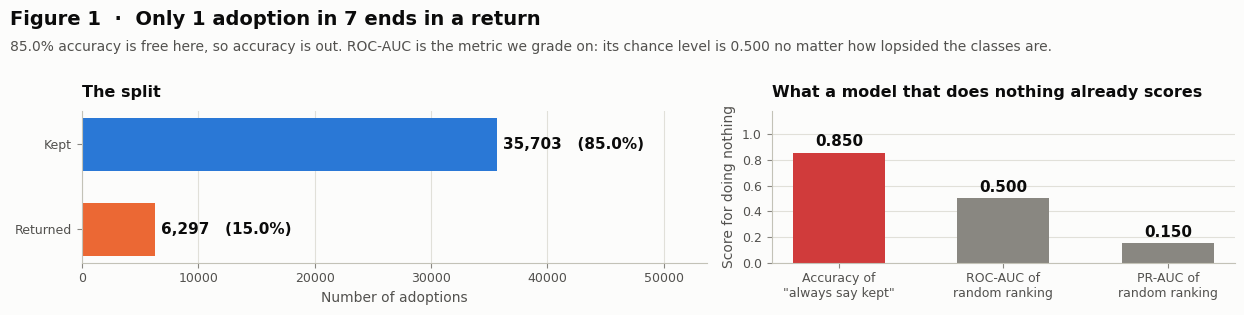

In [ ]:
# ===========================================================================
# FIGURE 1 -- the target, and what doing nothing already scores
# ===========================================================================
total = n_pos + n_neg

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.2),
                         gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
vals = [n_neg, n_pos]
bars = ax.barh(["Kept", "Returned"], vals, color=[KEPT, RETURNED], height=0.62)
for bar, v in zip(bars, vals):
    ax.text(v + total * 0.012, bar.get_y() + bar.get_height() / 2,
            f"{v:,}   ({v / total:.1%})", va="center", ha="left",
            fontsize=11, color=INK, fontweight="bold")
ax.set_xlim(0, total * 1.28)
ax.set_xlabel("Number of adoptions")
ax.invert_yaxis()
ax.set_title("The split")
tidy(ax, grid_axis="x")

ax = axes[1]
names = ['Accuracy of\n"always say kept"', "ROC-AUC of\nrandom ranking",
         "PR-AUC of\nrandom ranking"]
base_vals = [1 - pos_rate, 0.5, pos_rate]
bars = ax.bar(names, base_vals, color=[C_CRIT, MUTED, MUTED], width=0.56)
for bar, v in zip(bars, base_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.03, f"{v:.3f}",
            ha="center", va="bottom", fontsize=11, color=INK, fontweight="bold")
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score for doing nothing")
ax.set_title("What a model that does nothing already scores")
tidy(ax)

headline(fig, "Figure 1  ·  Only 1 adoption in 7 ends in a return",
         f"{1 - pos_rate:.1%} accuracy is free here, so accuracy is out. ROC-AUC is the "
         "metric we grade on: its chance level is 0.500 no matter how lopsided the classes are.")
save(fig, "01_class_balance")
plt.show()

## 1.2 Target leakage — check this before fitting anything

A leaked column is one that could not exist at the moment you need a prediction. Include one and the model looks superb in the notebook and is worthless in the shelter, because the field it depends on is blank for a brand-new adoption.

The screen below fits a depth-2 tree on **each column alone** and scores ROC-AUC. Anything near 1.0 is not a strong predictor — it is the answer wearing a hat.

Note the missingness column appended to every numeric field. Missingness itself can be the leak: a column that is blank for every kept dog and filled in for every returned one carries the target perfectly even though its *values* look innocent. Screening on values alone would miss `days_to_return` entirely.

In [ ]:
tic("leakage")
y_all = df[TARGET].to_numpy()
solo = {}

for col in [c for c in df.columns if c != TARGET]:
    s = df[col]
    if s.nunique() > 2000:                        # identifier-like, do not fit
        solo[col] = np.nan
        continue
    if not pd.api.types.is_numeric_dtype(s):
        # np.asarray keeps this working on pandas 2.x AND 3.x (Arrow-backed strings)
        x = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1
                           ).fit_transform(np.asarray(s.astype(str)).reshape(-1, 1))
    else:
        x = np.asarray(s, dtype=float).reshape(-1, 1)
        # encode MISSINGNESS explicitly -- it is often where the leak hides
        x = np.hstack([np.nan_to_num(x, nan=-999.0), np.isnan(x).astype(float)])
    t = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(x, y_all)
    solo[col] = roc_auc_score(y_all, t.predict_proba(x)[:, 1])

solo = pd.Series(solo).sort_values(ascending=False)
print("Single-column ROC-AUC (depth-2 tree). Chance = 0.500\n")
print(solo.head(6).round(4).to_string())

DROP_LEAKAGE = {
    "return_reason": (
        "Records WHY the dog came back. Only exists once a return has happened, and reads "
        "literally 'kept' for every non-return. A perfect target proxy."),
    "days_to_return": (
        "Days from adoption to return. Blank for every kept dog and a number for every "
        "returned one, so its MISSINGNESS alone is the target. Post-outcome by definition."),
}
DROP_ID = {
    "adoption_id": (
        "Unique key, 42,000 distinct values, zero signal. A tree will happily split on it "
        "and memorise the training set."),
}

print("\nDROPPED -- target leakage:")
for c, why in DROP_LEAKAGE.items():
    print(f"  x {c:<16} solo ROC-AUC = {solo[c]:.4f}\n      {why}")
print("\nDROPPED -- identifier:")
for c, why in DROP_ID.items():
    print(f"  x {c:<16}\n      {why}")
print("\nKEPT -- individually checked, all knowable at the moment of adoption:")
print("  previously_returned      history of a PRIOR adoption, not this one")
print("  days_in_shelter          length of stay BEFORE this adoption")
print("  visits_before_adoption   }")
print("  met_resident_pets        }  recorded during the adoption process, before placement")
print("  adoption_counseling      }")
print("  energy_mismatch          derived from pre-adoption dog + adopter fields")

drop_cols = list(DROP_LEAKAGE) + list(DROP_ID)
art["solo"] = solo
art["drop_leakage"], art["drop_id"] = DROP_LEAKAGE, DROP_ID
art["leak_crosstab"] = pd.crosstab(df["return_reason"], df[TARGET])
toc("leakage")

Single-column ROC-AUC (depth-2 tree). Chance = 0.500

return_reason         1.0000
days_to_return        1.0000
aggression_score      0.6561
anxiety_separation    0.6072
training_level        0.6007
reactivity_to_dogs    0.5937

DROPPED -- target leakage:
  x return_reason    solo ROC-AUC = 1.0000
      Records WHY the dog came back. Only exists once a return has happened, and reads literally 'kept' for every non-return. A perfect target proxy.
  x days_to_return   solo ROC-AUC = 1.0000
      Days from adoption to return. Blank for every kept dog and a number for every returned one, so its MISSINGNESS alone is the target. Post-outcome by definition.

DROPPED -- identifier:
  x adoption_id     
      Unique key, 42,000 distinct values, zero signal. A tree will happily split on it and memorise the training set.

KEPT -- individually checked, all knowable at the moment of adoption:
  previously_returned      history of a PRIOR adoption, not this one
  days_in_shelter          length of st

  saved figures/02_leakage_audit.png


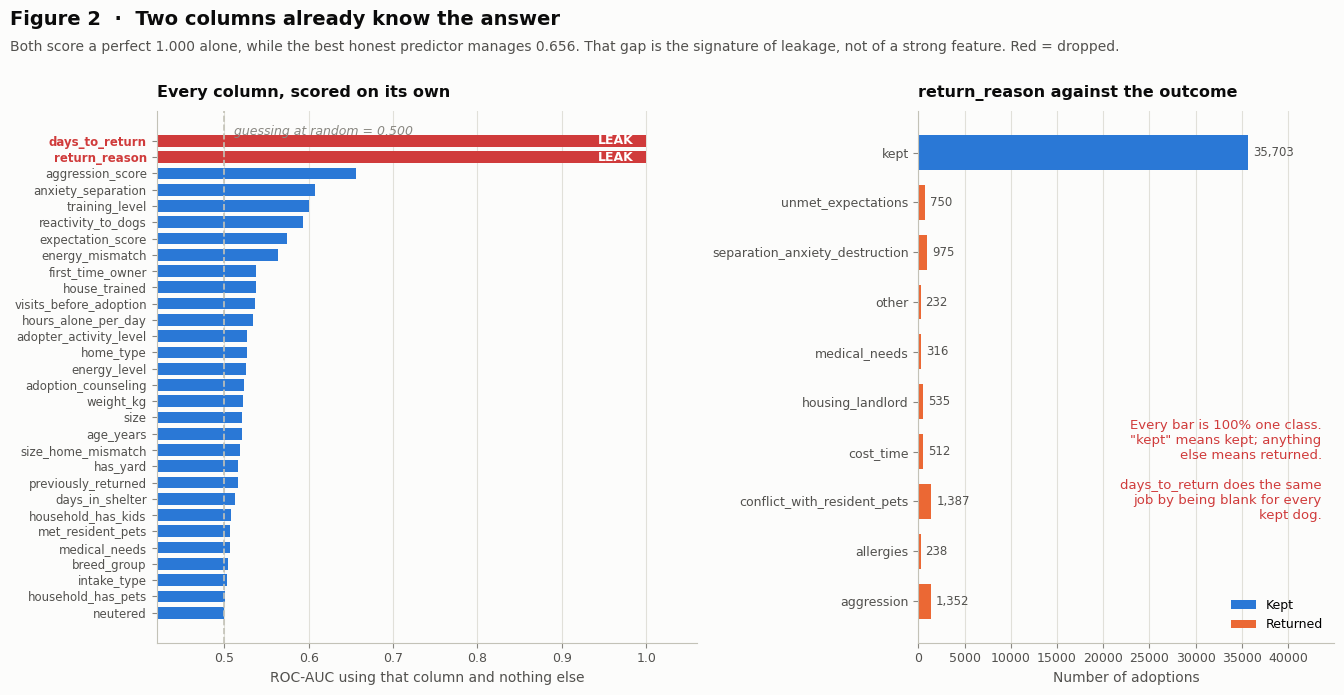

In [ ]:
# ===========================================================================
# FIGURE 2 -- the leakage audit, and the proof for the worst offender
# ===========================================================================
s = art["solo"].dropna().sort_values()
leak_names = set(art["drop_leakage"])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 7),
                         gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
ax.barh(range(len(s)), s.values, height=0.72,
        color=[C_CRIT if n in leak_names else C_BLUE for n in s.index])
ax.set_yticks(range(len(s)), list(s.index), fontsize=8.5)
for lbl, n in zip(ax.get_yticklabels(), s.index):
    if n in leak_names:
        lbl.set_color(C_CRIT)
        lbl.set_fontweight("bold")
ax.axvline(0.5, color=BASELINE, ls="--", lw=1.2)
ax.text(0.512, len(s) - 0.4, "guessing at random = 0.500", fontsize=9,
        color=MUTED, ha="left", va="center", style="italic")
for i, n in enumerate(s.index):
    if n in leak_names:
        ax.text(s.values[i] - 0.015, i, "LEAK", va="center", ha="right",
                color="white", fontweight="bold", fontsize=9)
ax.set_xlim(0.42, 1.06)
ax.set_xlabel("ROC-AUC using that column and nothing else")
ax.set_title("Every column, scored on its own")
tidy(ax, grid_axis="x")

ax = axes[1]
ct = art["leak_crosstab"]
ct = ct.loc[[i for i in ct.index if i != "kept"] + ["kept"]]
ypos = np.arange(len(ct))
ax.barh(ypos, ct[0].values, color=KEPT, height=0.7, label="Kept")
ax.barh(ypos, ct[1].values, left=ct[0].values, color=RETURNED, height=0.7,
        label="Returned")
ax.set_yticks(ypos, [str(i) for i in ct.index], fontsize=9)
for i, idx in enumerate(ct.index):
    tot = int(ct.loc[idx].sum())
    ax.text(tot + ct.values.max() * 0.015, i, f"{tot:,}", va="center",
            fontsize=8.5, color=INK2)
ax.set_xlim(0, ct.values.max() * 1.26)
ax.set_xlabel("Number of adoptions")
ax.set_title("return_reason against the outcome")
ax.legend(loc="lower right")
tidy(ax, grid_axis="x")
ax.text(0.97, 0.42,
        'Every bar is 100% one class.\n"kept" means kept; anything\nelse means returned.\n\n'
        "days_to_return does the same\njob by being blank for every\nkept dog.",
        transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color=C_CRIT)

best_honest = s[[i for i in s.index if i not in leak_names]].max()
headline(fig, "Figure 2  ·  Two columns already know the answer",
         f"Both score a perfect 1.000 alone, while the best honest predictor manages "
         f"{best_honest:.3f}. That gap is the signature of leakage, not of a strong feature. "
         "Red = dropped.")
save(fig, "02_leakage_audit")
plt.show()

## 1.3 What actually separates a returned dog from a kept one

Before any model, a look at the raw return rate across the columns the data dictionary flags as drivers. Four panels, no fitting — every one of them is a `groupby` on the dataframe.

This is the honest preview of how hard the problem is. The behaviour scores move the return rate a great deal; the household and process columns move it much less. Whatever the models find later has to come from somewhere in here.

  saved figures/03_what_drives_returns.png


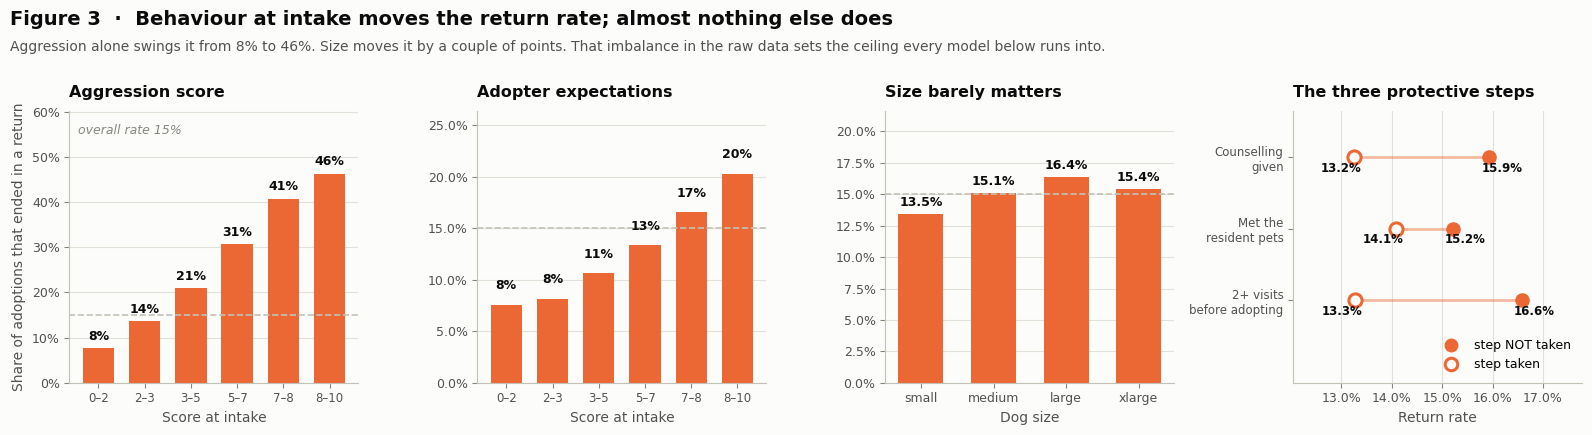

In [ ]:
# ===========================================================================
# FIGURE 3 -- what drives returns, straight off the raw data
# ===========================================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))


def rate_by_bins(col, n_bins=6):
    """Return rate across equal-width bins of a 0-10 behaviour score."""
    edges = np.linspace(df[col].min(), df[col].max(), n_bins + 1)
    b = pd.cut(df[col], bins=edges, include_lowest=True)
    g = df.groupby(b, observed=True)[TARGET].agg(["mean", "size"])
    # label off the edge array, not the interval: include_lowest nudges the
    # first left edge below the minimum, which formats as a stray "-0"
    g.index = [f"{edges[i]:.0f}–{edges[i + 1]:.0f}" for i in range(len(g))]
    return g


for ax, col, title in ((axes[0], "aggression_score", "Aggression score"),
                       (axes[1], "expectation_score", "Adopter expectations")):
    g = rate_by_bins(col)
    ax.bar(range(len(g)), g["mean"].values, color=RETURNED, width=0.68)
    for i, v in enumerate(g["mean"].values):
        ax.text(i, v + 0.012, f"{v:.0%}", ha="center", va="bottom",
                fontsize=9, color=INK, fontweight="bold")
    ax.axhline(pos_rate, color=BASELINE, ls="--", lw=1.2)
    ax.set_xticks(range(len(g)), list(g.index), fontsize=8.5)
    ax.set_ylim(0, max(g["mean"].max() * 1.30, 0.2))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("Score at intake")
    ax.set_title(title)
    tidy(ax)
axes[0].set_ylabel("Share of adoptions that ended in a return")
axes[0].text(0.03, 0.95, f"overall rate {pos_rate:.0%}", transform=axes[0].transAxes,
             fontsize=9, color=MUTED, style="italic", va="top")

ax = axes[2]
g = df.groupby("size", observed=True)[TARGET].mean().reindex(
    ["small", "medium", "large", "xlarge"])
ax.bar(range(len(g)), g.values, color=RETURNED, width=0.62)
for i, v in enumerate(g.values):
    ax.text(i, v + 0.004, f"{v:.1%}", ha="center", va="bottom", fontsize=9,
            color=INK, fontweight="bold")
ax.axhline(pos_rate, color=BASELINE, ls="--", lw=1.2)
ax.set_xticks(range(len(g)), list(g.index), fontsize=9)
ax.set_ylim(0, g.max() * 1.32)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Dog size")
ax.set_title("Size barely matters")
tidy(ax)

ax = axes[3]
# A dumbbell, not paired bars: both ends are the same quantity (the return
# rate), so they belong to one series in one colour. Colouring "step taken" and
# "step not taken" differently would spend two palette slots on a distinction
# the position already makes -- and the obvious choice, red vs green, is
# reserved here for status and never for a data series.
flags = [("adoption_counseling", "Counselling\ngiven"),
         ("met_resident_pets", "Met the\nresident pets"),
         ("visits_before_adoption", "2+ visits\nbefore adopting")]
without, with_ = [], []
for col, _ in flags:
    taken = (df[col] >= 2) if col == "visits_before_adoption" else (df[col] == 1)
    without.append(df.loc[~taken, TARGET].mean())
    with_.append(df.loc[taken, TARGET].mean())

ypos = np.arange(len(flags))
for i, (a_, b_) in enumerate(zip(without, with_)):
    ax.plot([a_, b_], [i, i], color=RETURNED, lw=2, alpha=0.45, zorder=1)
    ax.scatter([a_], [i], s=90, color=RETURNED, zorder=3)
    ax.scatter([b_], [i], s=90, facecolor=SURFACE, edgecolor=RETURNED,
               linewidth=2.2, zorder=3)
    ax.text(a_ + 0.0025, i + 0.24, f"{a_:.1%}", ha="center", va="bottom",
            fontsize=8.5, color=INK, fontweight="bold")
    ax.text(b_ - 0.0025, i + 0.24, f"{b_:.1%}", ha="center", va="bottom",
            fontsize=8.5, color=INK, fontweight="bold")
ax.set_yticks(ypos, [lab for _, lab in flags], fontsize=8.5)
ax.invert_yaxis()
# explicit limits after the invert: leaves a clear row of space under the last
# dumbbell for the legend, which otherwise lands on top of its value labels
ax.set_ylim(len(flags) + 0.15, -0.65)
ax.set_xlim(min(with_) - 0.012, max(without) + 0.012)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Return rate")
ax.set_title("The three protective steps")
ax.legend(handles=[
    Line2D([], [], marker="o", ls="", markersize=9, color=RETURNED,
           label="step NOT taken"),
    Line2D([], [], marker="o", ls="", markersize=9, markerfacecolor=SURFACE,
           markeredgecolor=RETURNED, markeredgewidth=2.2, color=RETURNED,
           label="step taken"),
], loc="lower right")
tidy(ax, grid_axis="x")

headline(fig, "Figure 3  ·  Behaviour at intake moves the return rate; almost nothing else does",
         f"Aggression alone swings it from {rate_by_bins('aggression_score')['mean'].iloc[0]:.0%} "
         f"to {rate_by_bins('aggression_score')['mean'].iloc[-1]:.0%}. Size moves it by a couple "
         "of points. That imbalance in the raw data sets the ceiling every model below runs into.")
save(fig, "03_what_drives_returns")
plt.show()

## 1.4 Split first, then encode

The test set is sealed here and not read again until each model's slot 5. Every hyperparameter and every threshold below is chosen by cross-validation **inside the training data**. The split is stratified, so both halves carry the same 15% return rate.

### Two encodings, one function — and why that is still uniform

There is one honest exception to "all four models get identical treatment", and it is worth stating rather than hiding:

- **`scale=True`** — ordinal codes for the ordered categories, one-hot for the unordered ones, then `StandardScaler` over **the entire encoded matrix**. Used by k-NN, the MLP and the nearest centroid.
- **`scale=False`** — the same encoding with no scaling. Used by the tree.

Trees split on rank order, so scaling a column cannot change a single split — it is pure wasted computation. Every other model here would be broken without it. k-NN and nearest centroid measure straight-line distance across all columns at once, and the MLP's gradient descent conditions badly on inputs with mismatched ranges.

Note the scaler covers the **whole** matrix, one-hot dummies included. Scaling only the numeric columns and letting dummies through as raw 0/1 is a subtle and common bug: a dummy has standard deviation around 0.36 against 1.0 for a scaled numeric, so every categorical silently contributes about a third of its fair share to the distance. That bug is in the original nearest-centroid code and Part 5 measures what it costs.

Both matrices come from the same rows, in the same order, with the same column names. The split indices and the cross-validation folds are built once, here, and reused by all four models.

In [ ]:
X_raw = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET].to_numpy()

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)

# Genuinely ordered categories get ordinal codes, so a split like "size <= 1.5"
# means "small or medium" -- a real statement. Unordered ones get one-hot;
# ordinal-coding them would invent an order that is not there.
ORDINAL_MAPS = {"size": ["small", "medium", "large", "xlarge"],
                "medical_needs": ["none", "minor", "chronic"]}
NOMINAL = ["breed_group", "intake_type", "home_type"]
ORDINAL_COLS = list(ORDINAL_MAPS)
NUMERIC_COLS = [c for c in X_raw.columns if c not in ORDINAL_COLS + NOMINAL]


def make_matrix(scale):
    """Encode train and test the same way. Fit on TRAIN only.

    scale=True puts a StandardScaler over the ENTIRE encoded matrix, one-hot
    dummies included -- see the note above. scale=False is for the tree, which
    splits on rank order and cannot be affected by scaling either way.
    """
    enc = ColumnTransformer([
        ("ord", OrdinalEncoder(categories=[ORDINAL_MAPS[c] for c in ORDINAL_COLS]),
         ORDINAL_COLS),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL),
        ("num", "passthrough", NUMERIC_COLS),
    ], remainder="drop")
    steps = [("encode", enc)] + ([("scale", StandardScaler())] if scale else [])
    pipe = Pipeline(steps).fit(X_tr_raw)
    cols = [f.split("__", 1)[1] for f in enc.get_feature_names_out()]
    return (pd.DataFrame(pipe.transform(X_tr_raw), columns=cols),
            pd.DataFrame(pipe.transform(X_te_raw), columns=cols))


X_tr_s, X_te_s = make_matrix(scale=True)     # k-NN, MLP, nearest centroid
X_tr_t, X_te_t = make_matrix(scale=False)    # decision tree
FEATURES = list(X_tr_s.columns)

# One fold list, built once, reused by all four models. Passing the same folds
# everywhere is what makes the cross-validated numbers comparable across parts.
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(cv.split(X_tr_s, y_tr))

print(f"train {X_tr_s.shape[0]:,} rows   positives {y_tr.sum():,} ({y_tr.mean():.2%})")
print(f"test  {X_te_s.shape[0]:,} rows   positives {y_te.sum():,} ({y_te.mean():.2%})")
print(f"encoded to {len(FEATURES)} columns "
      f"(ordinal {len(ORDINAL_COLS)}, one-hot {len(FEATURES) - len(ORDINAL_COLS) - len(NUMERIC_COLS)}, "
      f"numeric {len(NUMERIC_COLS)})")
print(f"{N_SPLITS}-fold stratified CV, folds built once and shared by every model")
print("\n>>> TEST SET SEALED. Nothing reads it until each model's scorecard. <<<")

art["features"] = FEATURES
art["y_te"], art["y_tr"] = y_te, y_tr
art["split_counts"] = pd.DataFrame(
    {"train": pd.Series(y_tr).value_counts().sort_index(),
     "test": pd.Series(y_te).value_counts().sort_index()})

train 31,500 rows   positives 4,723 (14.99%)
test  10,500 rows   positives 1,574 (14.99%)
encoded to 39 columns (ordinal 2, one-hot 14, numeric 23)
3-fold stratified CV, folds built once and shared by every model

>>> TEST SET SEALED. Nothing reads it until each model's scorecard. <<<


  saved figures/04_split_and_scaling.png


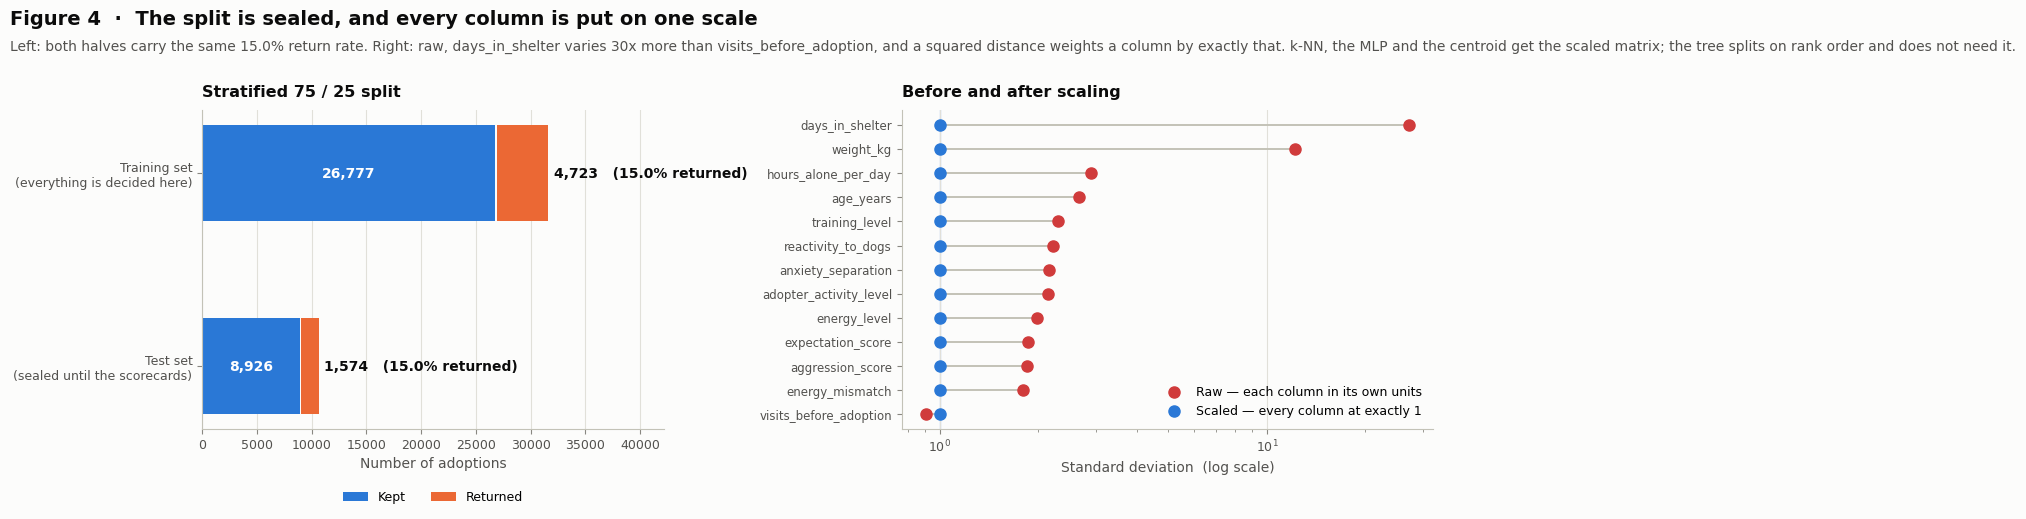

In [ ]:
# ===========================================================================
# FIGURE 4 -- the split, and what scaling does to the columns
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4),
                         gridspec_kw={"width_ratios": [1, 1.15]})

ax = axes[0]
sc = art["split_counts"]
rows = ["Training set\n(everything is decided here)",
        "Test set\n(sealed until the scorecards)"]
kept_n = [int(sc.loc[0, "train"]), int(sc.loc[0, "test"])]
ret_n = [int(sc.loc[1, "train"]), int(sc.loc[1, "test"])]
GAP = 130                       # a small surface gap so the segments stay distinct
ax.barh(rows, kept_n, color=KEPT, height=0.5, label="Kept")
ax.barh(rows, ret_n, left=np.array(kept_n) + GAP, color=RETURNED, height=0.5,
        label="Returned")
for i, (k, r) in enumerate(zip(kept_n, ret_n)):
    ax.text(k / 2, i, f"{k:,}", ha="center", va="center", color="white",
            fontsize=10, fontweight="bold")
    ax.text(k + GAP + r + 500, i, f"{r:,}   ({r / (k + r):.1%} returned)",
            va="center", ha="left", fontsize=10, color=INK, fontweight="bold")
ax.set_xlim(0, max(np.array(kept_n) + np.array(ret_n)) * 1.34)
ax.set_xlabel("Number of adoptions")
ax.invert_yaxis()
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.16))
ax.set_title("Stratified 75 / 25 split")
tidy(ax, grid_axis="x")

ax = axes[1]
# Standard deviation is the right summary here, because it is exactly what a
# squared distance weights a column by. Drawn as a dumbbell on a log axis:
# ranges spanning three orders of magnitude cannot share a linear axis, and
# bars cannot start at zero on a log one.
show = [c for c in NUMERIC_COLS if X_tr_raw[c].nunique() > 2]
sd_raw = X_tr_raw[show].std().sort_values()
order = sd_raw.index.tolist()
ypos = np.arange(len(order))

for i, c in enumerate(order):
    ax.plot([sd_raw[c], 1.0], [i, i], color=BASELINE, lw=1.4, zorder=1)
ax.scatter(sd_raw.values, ypos, s=64, color=C_CRIT, zorder=3,
           label="Raw — each column in its own units")
ax.scatter(np.ones(len(order)), ypos, s=64, color=C_BLUE, zorder=4,
           label="Scaled — every column at exactly 1")
ax.set_yticks(ypos, order, fontsize=8.5)
ax.set_xscale("log")
ax.axvline(1.0, color=C_BLUE, lw=1.0, alpha=0.35, zorder=0)
ax.set_xlabel("Standard deviation  (log scale)")
ax.legend(loc="lower right")
ax.set_title("Before and after scaling")
tidy(ax, grid_axis="x")

widest, narrow = sd_raw.index[-1], sd_raw.index[0]
ratio = sd_raw.iloc[-1] / sd_raw.iloc[0]
headline(fig, "Figure 4  ·  The split is sealed, and every column is put on one scale",
         f"Left: both halves carry the same {y_tr.mean():.1%} return rate. Right: raw, "
         f"{widest} varies {ratio:.0f}x more than {narrow}, and a squared distance weights a "
         "column by exactly that. k-NN, the MLP and the centroid get the scaled matrix; the "
         "tree splits on rank order and does not need it.")
save(fig, "04_split_and_scaling")
plt.show()

---
# Part 2 · k-Nearest Neighbours

**The idea in one sentence:** to predict a new adoption, find the *k* past adoptions that look most like it and take a vote.

There is no equation to fit and nothing is learned at training time — the model *is* the training data. The only decisions are how many neighbours get a vote, and whether closer ones count more.

**Why the scaling in Part 1 was mandatory here.** k-NN adds up differences across every column at once to decide what "similar" means. Unscaled, `days_in_shelter` would swamp `aggression_score` purely because it is measured in bigger numbers.

## 2.1 · Slot 1 — Tuning: how many neighbours?

Small *k* means a jumpy model that chases individual dogs. Large *k* means a smooth one that may blur the signal away. There is no way to reason it out; you sweep it and cross-validate.

⏱️ **The slowest cell in this part** — roughly 1–2 minutes.

In [ ]:
tic("knn")
# The grid runs past where the curve turns over on purpose. Stopping at the
# best value you happened to try tells you nothing about whether it is a peak
# or just the edge of the grid.
K_GRID = [11, 25, 51, 101, 201, 401, 801, 1601, 3201, 6401]
knn_curve = {}

for w in ("uniform", "distance"):
    for k in K_GRID:
        m = KNeighborsClassifier(n_neighbors=k, weights=w, n_jobs=N_JOBS)
        knn_curve[(w, k)] = cross_val_score(m, X_tr_s, y_tr, cv=folds,
                                            scoring="roc_auc", n_jobs=1).mean()
    print(f"  {w:<9} " + "  ".join(f"k={k}:{knn_curve[(w, k)]:.4f}" for k in K_GRID))

(best_w, best_k), best_knn_cv = max(knn_curve.items(), key=lambda kv: kv[1])
print(f"\nbest: k={best_k}, weights={best_w}   CV ROC-AUC = {best_knn_cv:.4f}")

knn = KNeighborsClassifier(n_neighbors=best_k, weights=best_w, n_jobs=N_JOBS)
knn.fit(X_tr_s, y_tr)
art["knn_curve"], art["knn_best"] = knn_curve, (best_w, best_k, best_knn_cv)
toc("knn")

  uniform   k=11:0.6184  k=25:0.6470  k=51:0.6747  k=101:0.6967  k=201:0.7138  k=401:0.7285  k=801:0.7361  k=1601:0.7423  k=3201:0.7452  k=6401:0.7463
  distance  k=11:0.6213  k=25:0.6498  k=51:0.6758  k=101:0.6976  k=201:0.7142  k=401:0.7287  k=801:0.7363  k=1601:0.7423  k=3201:0.7453  k=6401:0.7465

best: k=6401, weights=distance   CV ROC-AUC = 0.7465
   [knn: 456.6s]


  saved figures/05_knn_choosing_k.png


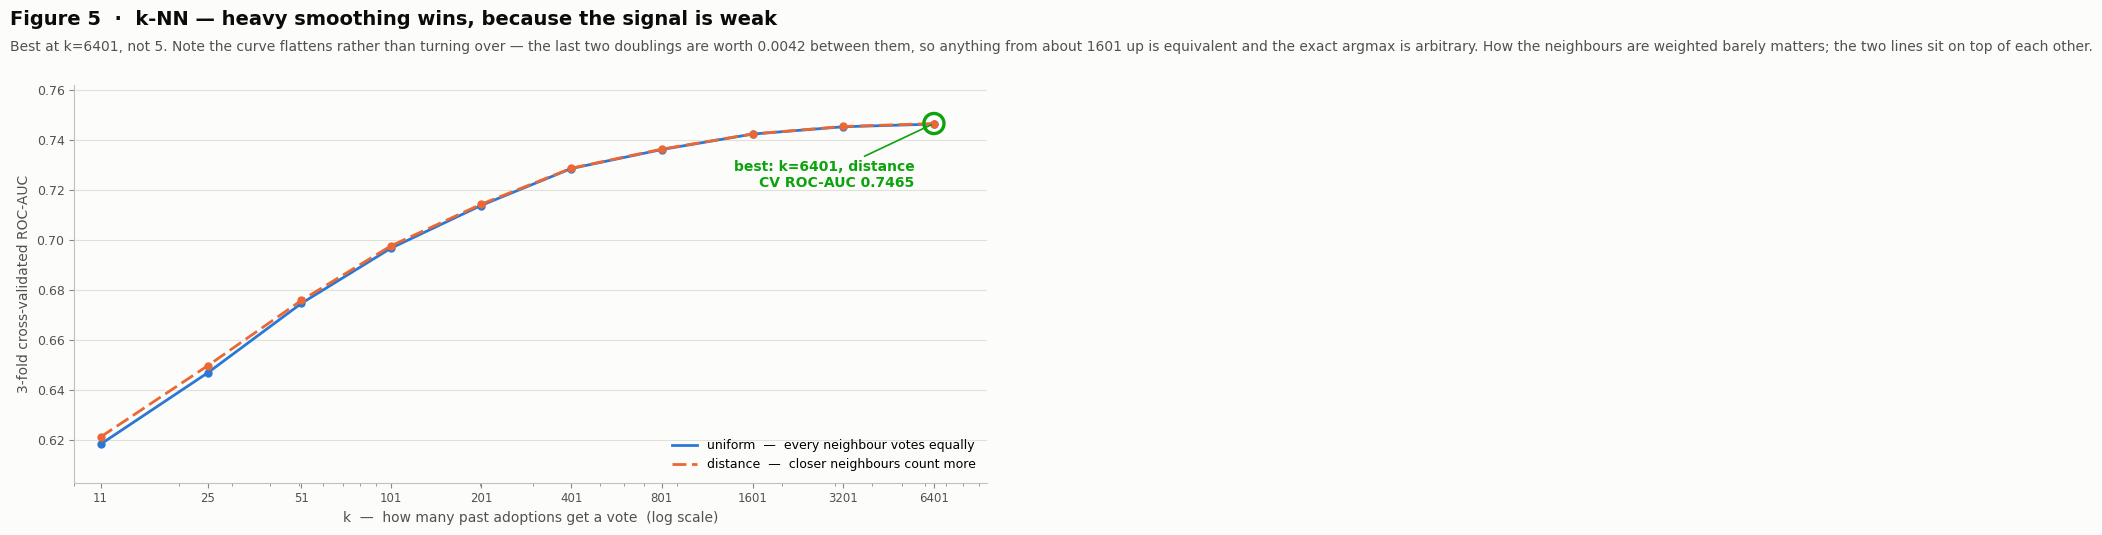

In [ ]:
# ===========================================================================
# FIGURE 5 -- SLOT 1: choosing k
# ===========================================================================
fig, ax = plt.subplots(figsize=(10, 5.4))

# No direct end-labels here: the two weightings score within ~0.002 of each
# other at every k, so their labels would land on top of one another. The
# legend names both, and the near-perfect overlap is itself the finding.
for w, colour, style in (("uniform", C_BLUE, "solid"),
                         ("distance", C_ORANGE, (0, (5, 2)))):
    ax.plot(K_GRID, [knn_curve[(w, k)] for k in K_GRID], marker="o",
            markersize=5, color=colour, linestyle=style)

ax.scatter([best_k], [best_knn_cv], s=210, facecolors="none", edgecolors=C_GOOD,
           linewidths=2.4, zorder=5)
ax.annotate(f"best: k={best_k}, {best_w}\nCV ROC-AUC {best_knn_cv:.4f}",
            (best_k, best_knn_cv), xytext=(-14, -46), textcoords="offset points",
            ha="right", fontsize=10, color=C_GOOD, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=C_GOOD, lw=1.2))

lo_y = min(knn_curve.values())
hi_y = max(knn_curve.values())
pad = (hi_y - lo_y) * 0.12
ax.set_xscale("log")
ax.set_xticks(K_GRID, [str(k) for k in K_GRID], fontsize=8.5)
ax.set_xlim(9, K_GRID[-1] * 1.5)
ax.set_ylim(lo_y - pad, hi_y + pad)
ax.set_xlabel("k  —  how many past adoptions get a vote  (log scale)")
ax.set_ylabel(f"{N_SPLITS}-fold cross-validated ROC-AUC")
ax.legend(handles=[
    Line2D([], [], color=C_BLUE, lw=2, ls="solid",
           label="uniform  —  every neighbour votes equally"),
    Line2D([], [], color=C_ORANGE, lw=2, ls=(0, (5, 2)),
           label="distance  —  closer neighbours count more"),
], loc="lower right")
tidy(ax)
last_gain = knn_curve[(best_w, K_GRID[-1])] - knn_curve[(best_w, K_GRID[-3])]
headline(fig, "Figure 5  ·  k-NN — heavy smoothing wins, because the signal is weak",
         f"Best at k={best_k}, not 5. Note the curve flattens rather than turning over — the "
         f"last two doublings are worth {last_gain:.4f} between them, so anything from about "
         f"{K_GRID[-3]} up is equivalent and the exact argmax is arbitrary. How the neighbours "
         "are weighted barely matters; the two lines sit on top of each other.")
save(fig, "05_knn_choosing_k")
plt.show()

## 2.2 · Slot 2 — Mechanics: why k-NN is the model that suffers from extra columns

This is the one figure that explains k-NN's central weakness, and it involves no model at all — it is arithmetic.

To collect a fixed *fraction* of the data as neighbours, the neighbourhood has to stretch across a fraction `f^(1/d)` of each axis, where `d` is the number of columns. That grows brutally fast. With one column the nearest neighbours are genuinely nearby; with 39 they span most of every column's range, and "similar" stops meaning much.

This is why feature selection is load-bearing for k-NN and merely tidy for a tree: every irrelevant column actively corrupts the distance, whereas a tree simply declines to split on it.

  saved figures/06_knn_curse_of_dimensionality.png


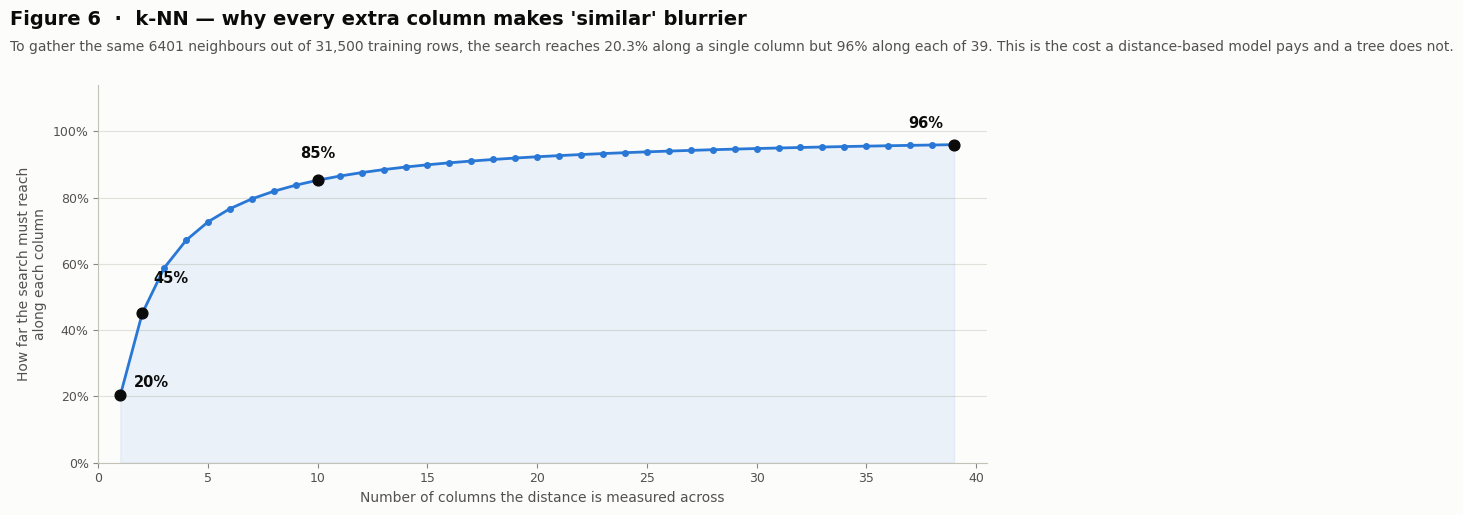

In [ ]:
# ===========================================================================
# FIGURE 6 -- SLOT 2: the curse of dimensionality. Pure arithmetic, no fitting.
# ===========================================================================
frac = best_k / len(X_tr_s)
dims = np.arange(1, len(FEATURES) + 1)
reach = frac ** (1 / dims)

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(dims, reach, color=C_BLUE, marker="o", markersize=4)
ax.fill_between(dims, 0, reach, color=C_BLUE, alpha=0.08)
for d, (dx, dy, ha) in {1: (10, 6, "left"), 2: (8, 22, "left"),
                        10: (0, 16, "center"),
                        len(FEATURES): (-8, 12, "right")}.items():
    ax.scatter([d], [reach[d - 1]], s=60, color=INK, zorder=5)
    ax.annotate(f"{reach[d - 1]:.0%}", (d, reach[d - 1]), xytext=(dx, dy),
                textcoords="offset points", ha=ha, fontsize=10.5, color=INK,
                fontweight="bold")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.14)
ax.set_xlim(0, len(FEATURES) + 1.5)
ax.set_xlabel("Number of columns the distance is measured across")
ax.set_ylabel("How far the search must reach\nalong each column")
tidy(ax)
headline(fig, "Figure 6  ·  k-NN — why every extra column makes 'similar' blurrier",
         f"To gather the same {best_k} neighbours out of {len(X_tr_s):,} training rows, the "
         f"search reaches {reach[0]:.1%} along a single column but {reach[len(FEATURES) - 1]:.0%} "
         f"along each of {len(FEATURES)}. This is the cost a distance-based model pays and a "
         "tree does not.")
save(fig, "06_knn_curse_of_dimensionality")
plt.show()

## 2.3 · Slots 3, 4 and 5 — threshold, importance, scorecard

`KNeighborsClassifier` has no `class_weight`, so the only lever for the 15% imbalance is where the cut-off goes. Its `predict_proba` is the weighted share of the *k* neighbours that were returns — and with returns this rare, no dog's neighbourhood is ever a majority "returned", so the default 0.5 cut-off flags nobody at all.

Permutation importance is fitted on a training subsample here (k-NN re-scores the entire neighbour search for every shuffle, which is the one genuinely expensive importance calculation of the four).

⏱️ Roughly 1–3 minutes for the three cells together.

cut-off 0.1493  ->  CV precision 0.300, recall 0.601
  saved figures/07_knn_threshold.png


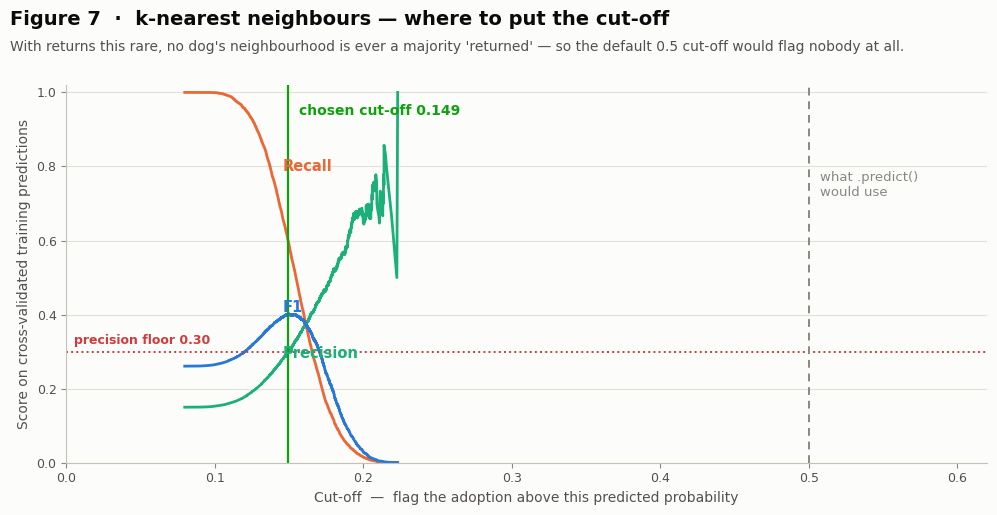

                           mean      std
aggression_score        0.07652  0.00538
anxiety_separation      0.02448  0.00284
energy_mismatch         0.01732  0.00363
training_level          0.01583  0.00541
reactivity_to_dogs      0.01229  0.00218
visits_before_adoption  0.01039  0.00229
  saved figures/08_knn_importance.png


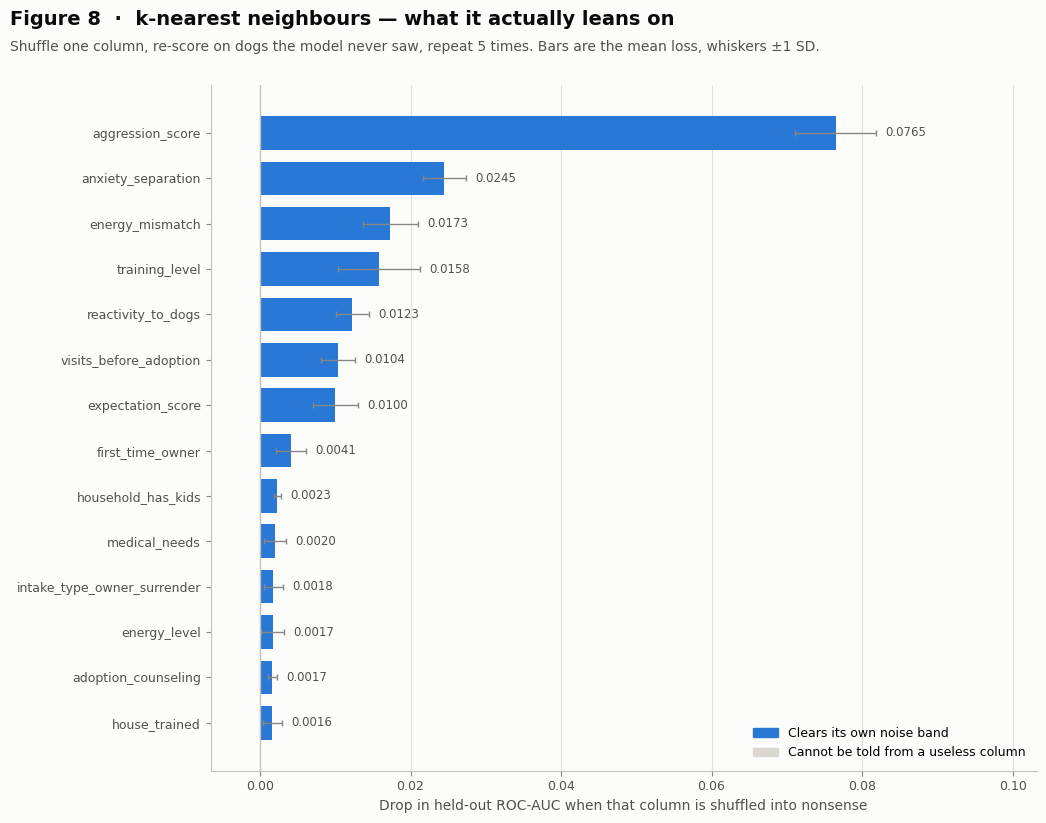

  k-nearest neighbours     ROC-AUC 0.7548 | PR-AUC 0.3760 | recall 0.646 | precision 0.303 | caught 1,017 of 1,574
  saved figures/09_knn_scorecard.png


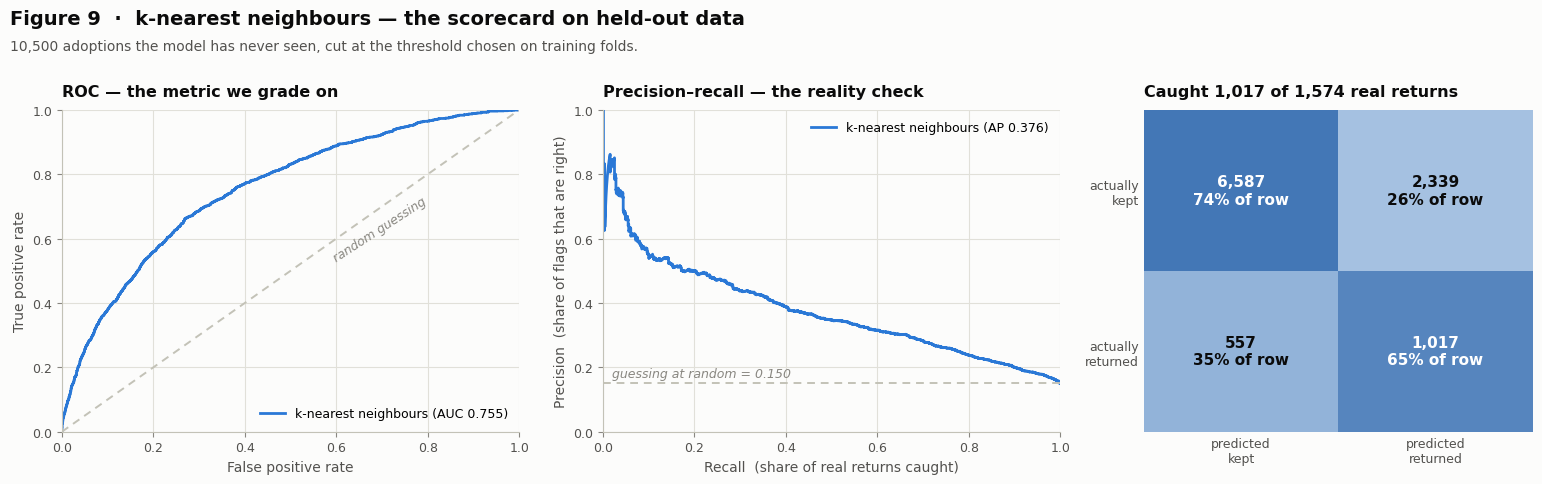

   [knn_rest: 475.9s]


In [ ]:
tic("knn_rest")

# --- SLOT 3: threshold, chosen on out-of-fold training predictions ----------
knn_cv_score = cv_scores(knn, X_tr_s, y_tr, folds)
knn_thr, knn_p, knn_r = tune_threshold(y_tr, knn_cv_score)
print(f"cut-off {knn_thr:.4f}  ->  CV precision {knn_p:.3f}, recall {knn_r:.3f}")
threshold_fig(7, "k-nearest neighbours", y_tr, knn_cv_score, knn_thr,
              "07_knn_threshold",
              note="With returns this rare, no dog's neighbourhood is ever a majority "
                   "'returned' — so the default 0.5 cut-off would flag nobody at all.")

# --- SLOT 4: permutation importance ----------------------------------------
# Carved out of TRAIN. The test set is still sealed at this point.
Xf, Xv, yf, yv = train_test_split(X_tr_s, y_tr, test_size=0.25,
                                  random_state=SEED, stratify=y_tr)
sub = np.random.RandomState(SEED).choice(len(Xf), min(KNN_PERM_SUB, len(Xf)),
                                         replace=False)
knn_small = KNeighborsClassifier(n_neighbors=max(11, int(best_k * len(sub) / len(Xf))),
                                 weights=best_w, n_jobs=N_JOBS)
knn_small.fit(Xf.iloc[sub], yf[sub])
pi = permutation_importance(knn_small, Xv.iloc[:3000], yv[:3000], scoring="roc_auc",
                            n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=N_JOBS)
knn_perm = pd.DataFrame({"mean": pi.importances_mean, "std": pi.importances_std},
                        index=FEATURES).sort_values("mean", ascending=False)
print(knn_perm.head(6).round(5).to_string())
perm_fig(8, "k-nearest neighbours", knn_perm, "08_knn_importance")

# --- SLOT 5: the scorecard, first read of the test set ----------------------
knn_test = knn.predict_proba(X_te_s)[:, 1]
r_knn = evaluate("k-nearest neighbours", y_te, knn_test, knn_thr)
scorecard_fig(9, "k-nearest neighbours", y_te, r_knn, fname="09_knn_scorecard")

art["knn_perm"], art["knn_thr"] = knn_perm, knn_thr
toc("knn_rest")

---
# Part 3 · Decision tree

**The idea in one sentence:** ask a sequence of yes/no questions about the dog and the home, and each answer narrows down to a group of past adoptions with a known return rate.

Unlike k-NN, a tree *learns* something at training time: which question to ask, in what order. It picks each split greedily — at every node it tries every column and every cut point, and takes whichever separates returns from keeps best.

**Why this model gets the unscaled matrix.** A tree splits on rank order, so multiplying a column by a thousand cannot change a single decision. Scaling it would be wasted arithmetic.

## 3.1 · Slot 1 — Tuning: how hard to prune

Left alone, a tree grows until every leaf is pure — it memorises the training set. Cost-complexity pruning fixes that by charging a fee `α` per leaf, so the tree minimises

> total leaf impurity + α × (number of leaves)

Sweep `α` upward and you get a nested sequence of ever-smaller trees.

**The trap is picking α by eye.** Training impurity falls monotonically as α shrinks, so looking at the tree's own fit always argues for the biggest possible tree. α has to be chosen on data the tree did not fit — that is the only place overfitting becomes visible.

`class_weight="balanced"` reweights the rare class so splits are not swamped by the 85% majority. This is a lever k-NN does not have, and it is why the tree needs less help from its threshold.

In [ ]:
tic("tree")
N_ALPHAS = 20 if FAST_MODE else 40

base = DecisionTreeClassifier(random_state=SEED, class_weight="balanced")
path = base.cost_complexity_pruning_path(X_tr_t, y_tr)
alphas_full = path.ccp_alphas[:-1]          # drop the root-only tree
lo = max(alphas_full[alphas_full > 0].min(), 1e-6)
alpha_grid = np.unique(np.geomspace(lo, alphas_full.max(), N_ALPHAS))
print(f"{len(alphas_full):,} distinct pruning fees on the path; "
      f"cross-validating {len(alpha_grid)} log-spaced ones\n")

tree_cv_mean, tree_cv_std, tree_leaves = [], [], []
for a in alpha_grid:
    fold_scores = []
    for tr_i, va_i in folds:
        m = DecisionTreeClassifier(random_state=SEED, class_weight="balanced",
                                   ccp_alpha=a).fit(X_tr_t.iloc[tr_i], y_tr[tr_i])
        fold_scores.append(roc_auc_score(y_tr[va_i],
                                         m.predict_proba(X_tr_t.iloc[va_i])[:, 1]))
    tree_cv_mean.append(np.mean(fold_scores))
    tree_cv_std.append(np.std(fold_scores))
    tree_leaves.append(DecisionTreeClassifier(
        random_state=SEED, class_weight="balanced",
        ccp_alpha=a).fit(X_tr_t, y_tr).get_n_leaves())

tree_cv_mean, tree_cv_std = np.array(tree_cv_mean), np.array(tree_cv_std)
tree_leaves = np.array(tree_leaves)
bi = int(np.argmax(tree_cv_mean))
best_alpha = float(alpha_grid[bi])

tree = DecisionTreeClassifier(random_state=SEED, class_weight="balanced",
                              ccp_alpha=best_alpha).fit(X_tr_t, y_tr)
print(f"best pruning fee = {best_alpha:.3e}   CV ROC-AUC = {tree_cv_mean[bi]:.4f} "
      f"+/- {tree_cv_std[bi]:.4f}")
print(f"final tree: {tree.get_n_leaves()} leaves, {tree.tree_.node_count} nodes, "
      f"depth {tree.get_depth()}")

art.update(alpha_grid=alpha_grid, tree_cv_mean=tree_cv_mean,
           tree_cv_std=tree_cv_std, tree_leaves=tree_leaves, best_alpha=best_alpha)
toc("tree")

2,660 distinct pruning fees on the path; cross-validating 20 log-spaced ones

best pruning fee = 6.571e-04   CV ROC-AUC = 0.6850 +/- 0.0008
final tree: 26 leaves, 51 nodes, depth 7
   [tree: 41.8s]


  saved figures/10_tree_pruning.png


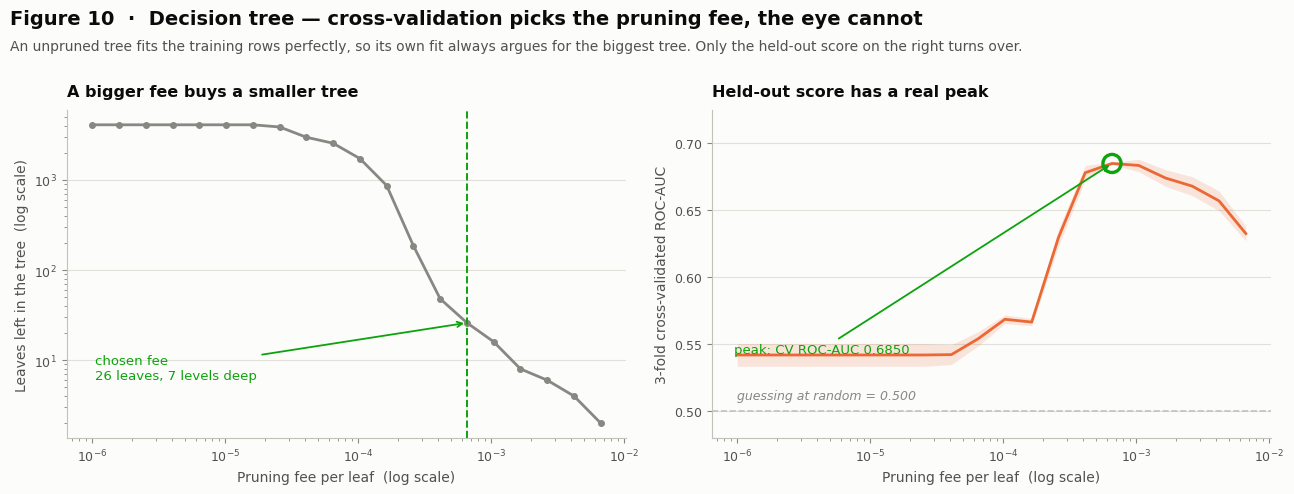

In [ ]:
# ===========================================================================
# FIGURE 10 -- SLOT 1: choosing the pruning fee
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

ax = axes[0]
ax.plot(alpha_grid, tree_leaves, color=MUTED, marker="o", markersize=4)
ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(best_alpha, color=C_GOOD, ls="--", lw=1.4)
ax.annotate(f"chosen fee\n{tree.get_n_leaves()} leaves, {tree.get_depth()} levels deep",
            xy=(best_alpha, tree_leaves[bi]), xytext=(0.05, 0.18),
            textcoords="axes fraction", fontsize=9.5, color=C_GOOD,
            arrowprops=dict(arrowstyle="->", color=C_GOOD, lw=1.3))
ax.set_xlabel("Pruning fee per leaf  (log scale)")
ax.set_ylabel("Leaves left in the tree  (log scale)")
ax.set_title("A bigger fee buys a smaller tree")
tidy(ax)

ax = axes[1]
ax.plot(alpha_grid, tree_cv_mean, color=C_ORANGE, zorder=3)
ax.fill_between(alpha_grid, tree_cv_mean - tree_cv_std, tree_cv_mean + tree_cv_std,
                color=C_ORANGE, alpha=0.16, lw=0)
ax.set_xscale("log")
ax.axhline(0.5, color=BASELINE, ls="--", lw=1.2)
ax.text(alpha_grid[0], 0.507, "guessing at random = 0.500", fontsize=9,
        color=MUTED, style="italic", va="bottom")
ax.scatter([best_alpha], [tree_cv_mean[bi]], s=170, facecolor="none",
           edgecolor=C_GOOD, linewidth=2.4, zorder=5)
ax.annotate(f"peak: CV ROC-AUC {tree_cv_mean[bi]:.4f}", xy=(best_alpha, tree_cv_mean[bi]),
            xytext=(0.04, 0.26), textcoords="axes fraction", fontsize=9.5,
            color=C_GOOD, arrowprops=dict(arrowstyle="->", color=C_GOOD, lw=1.3))
ax.set_xlabel("Pruning fee per leaf  (log scale)")
ax.set_ylabel(f"{N_SPLITS}-fold cross-validated ROC-AUC")
ax.set_ylim(0.48, tree_cv_mean.max() + 0.04)
ax.set_title("Held-out score has a real peak")
tidy(ax)

headline(fig, "Figure 10  ·  Decision tree — cross-validation picks the pruning fee, the eye cannot",
         "An unpruned tree fits the training rows perfectly, so its own fit always argues for "
         "the biggest tree. Only the held-out score on the right turns over.")
save(fig, "10_tree_pruning")
plt.show()

## 3.2 · Slot 2 — Mechanics: the tree itself

This is the one model in the notebook you can literally read. Drawn to depth 3.

**An important caveat, stated rather than buried:** the boxes at the bottom of this drawing are **not** final predictions. They are internal nodes with the rest of the tree hidden underneath. The tuned tree is far bigger than three levels — the cell prints its real size — so do not quote numbers off this picture as model performance. It is here to show the *shape* of the reasoning, and the top splits genuinely do tell the story.

Colours are repainted to the house palette. sklearn's default fills class 0 orange and class 1 blue, which is the exact inverse of *kept* / *returned* everywhere else in this notebook.

  saved figures/11_tree_structure.png


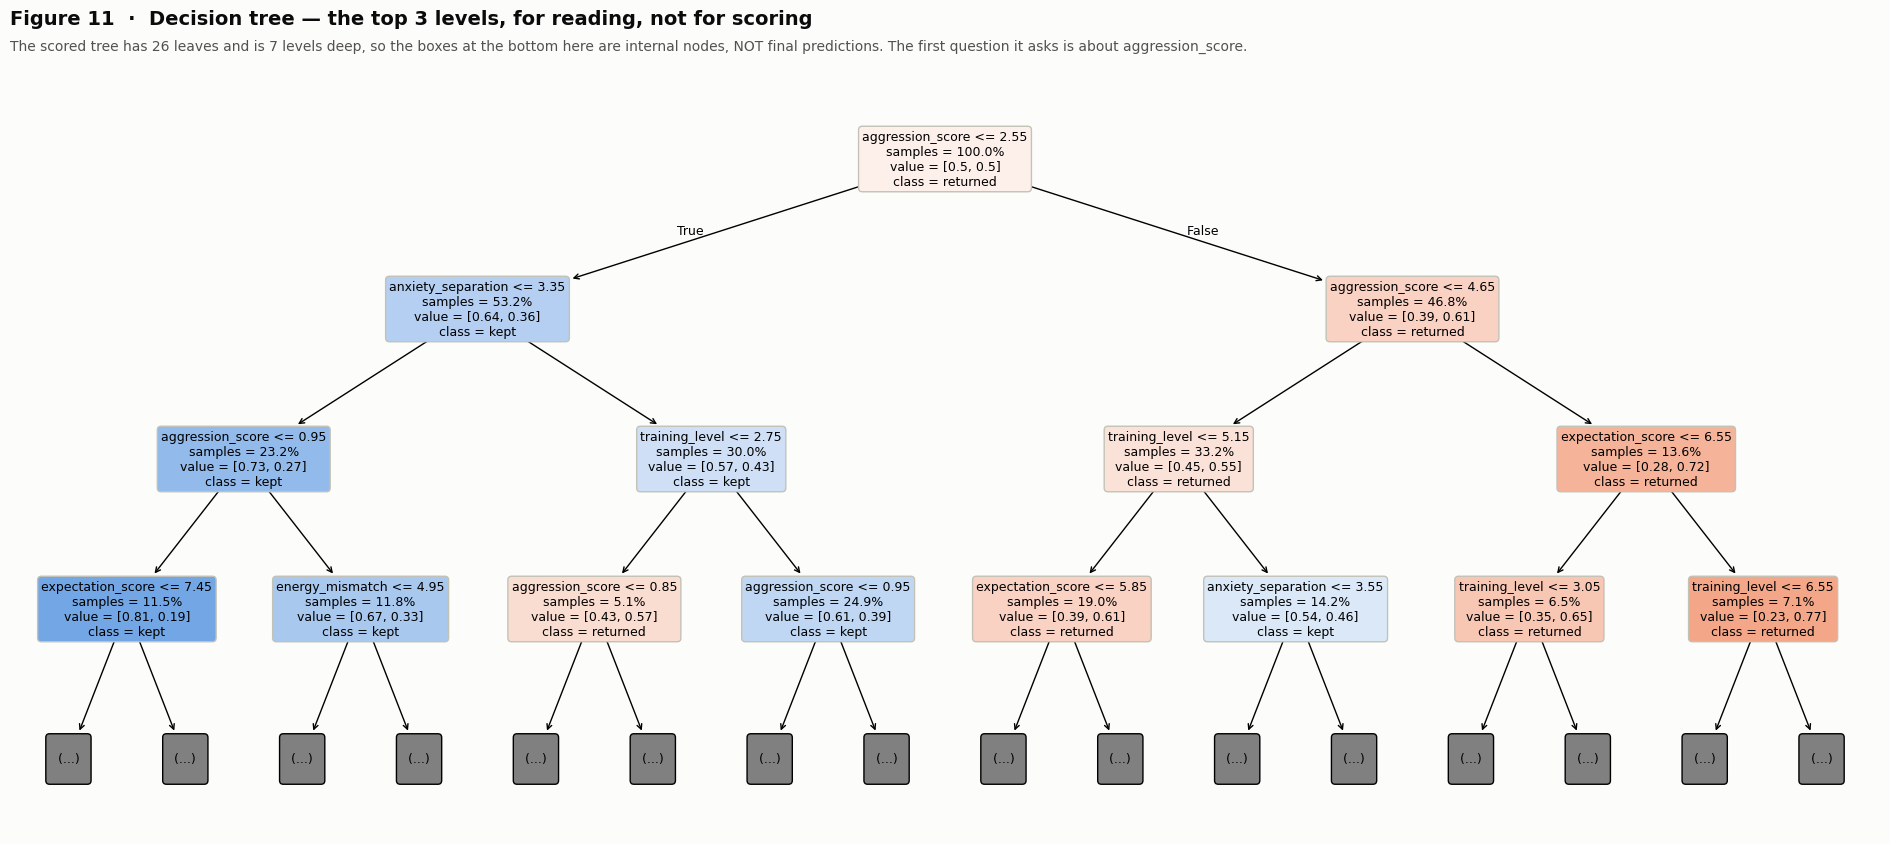

In [ ]:
# ===========================================================================
# FIGURE 11 -- SLOT 2: the tree, drawn to depth 3
# ===========================================================================
import re


def recolor_tree(artists):
    """Repaint plot_tree nodes into the house palette.

    sklearn fills nodes from a default colormap where class 0 (kept) comes out
    ORANGE and class 1 (returned) comes out BLUE -- the exact inverse of the
    KEPT / RETURNED convention used by every other figure here. Left alone this
    figure would say the opposite of the rest of the notebook. Shade tracks how
    pure the node is.
    """
    for a_ in artists:
        t = a_.get_text()
        if "class = " not in t:
            continue                       # a truncated "(...)" node
        base_col = RETURNED if t.rstrip().endswith("returned") else KEPT
        m = re.search(r"value = \[([\d.]+), ([\d.]+)\]", t)
        if m:
            p, q = float(m.group(1)), float(m.group(2))
            strength = (max(p, q) / max(p + q, 1e-9) - 0.5) * 2
        else:
            strength = 0.5
        rgb = matplotlib.colors.to_rgb(base_col)
        patch = a_.get_bbox_patch()
        if patch is not None:
            patch.set_facecolor(tuple(1 - (1 - c) * (0.10 + 0.90 * strength) for c in rgb))
            patch.set_edgecolor(BASELINE)


fig, ax = plt.subplots(figsize=(19, 8.5))
arts = plot_tree(tree, feature_names=FEATURES, class_names=["kept", "returned"],
                 filled=True, rounded=True, impurity=False, proportion=True,
                 fontsize=9, max_depth=3, ax=ax, precision=2)
recolor_tree(arts)
ax.set_axis_off()
root_split = FEATURES[tree.tree_.feature[0]]
headline(fig, "Figure 11  ·  Decision tree — the top 3 levels, for reading, not for scoring",
         f"The scored tree has {tree.get_n_leaves()} leaves and is {tree.get_depth()} levels "
         f"deep, so the boxes at the bottom here are internal nodes, NOT final predictions. "
         f"The first question it asks is about {root_split}.")
save(fig, "11_tree_structure")
plt.show()

## 3.3 · Slots 3, 4 and 5 — threshold, importance, scorecard

Slot 5 carries one extra curve: a **random forest**, which is hundreds of deep trees fitted to bootstrap samples with each split restricted to a random subset of columns, then averaged. Averaging cancels the variance a single deep tree suffers from.

The forest is not one of the four models being compared — it is here to answer one question inside this section: *how much does a single readable tree give up against a crowd of unreadable ones?* It is drawn in grey throughout so it is never mistaken for a fifth contender.

A note on importance, since trees make it tempting to take a shortcut. `tree.feature_importances_` is free — it falls out of training — but it is measured **in-sample** and it is **biased by cardinality**: a column with thousands of distinct values offers thousands of candidate split points, while a yes/no column offers one, so the many-valued column wins more often even when both are pure noise. Permutation importance on held-out data has neither problem, which is exactly why all four sections here use it.

cut-off 0.6680  ->  CV precision 0.306, recall 0.355
  saved figures/12_tree_threshold.png


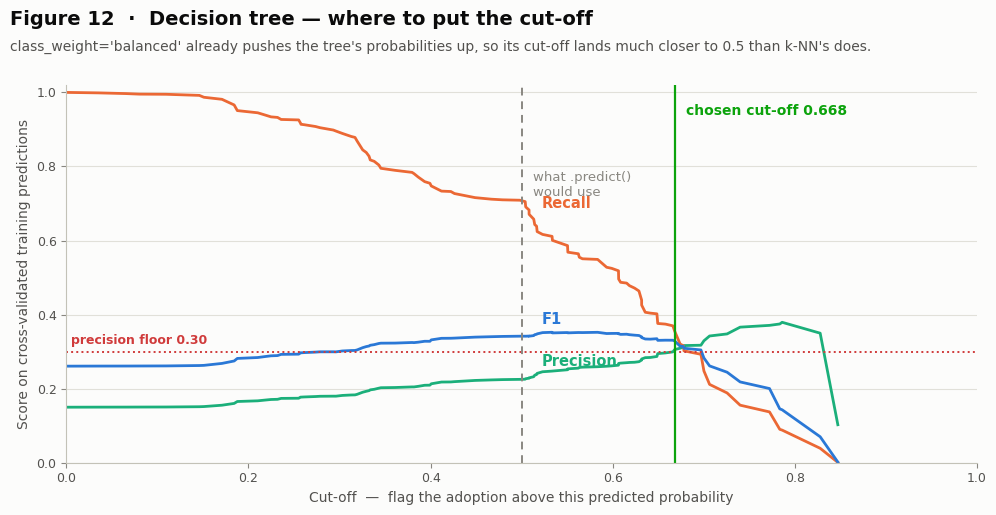

                       mean      std
aggression_score    0.11008  0.00519
expectation_score   0.02485  0.00265
anxiety_separation  0.02122  0.00201
training_level      0.01608  0.00143
energy_mismatch     0.00879  0.00193
weight_kg           0.00249  0.00078
  saved figures/13_tree_importance.png


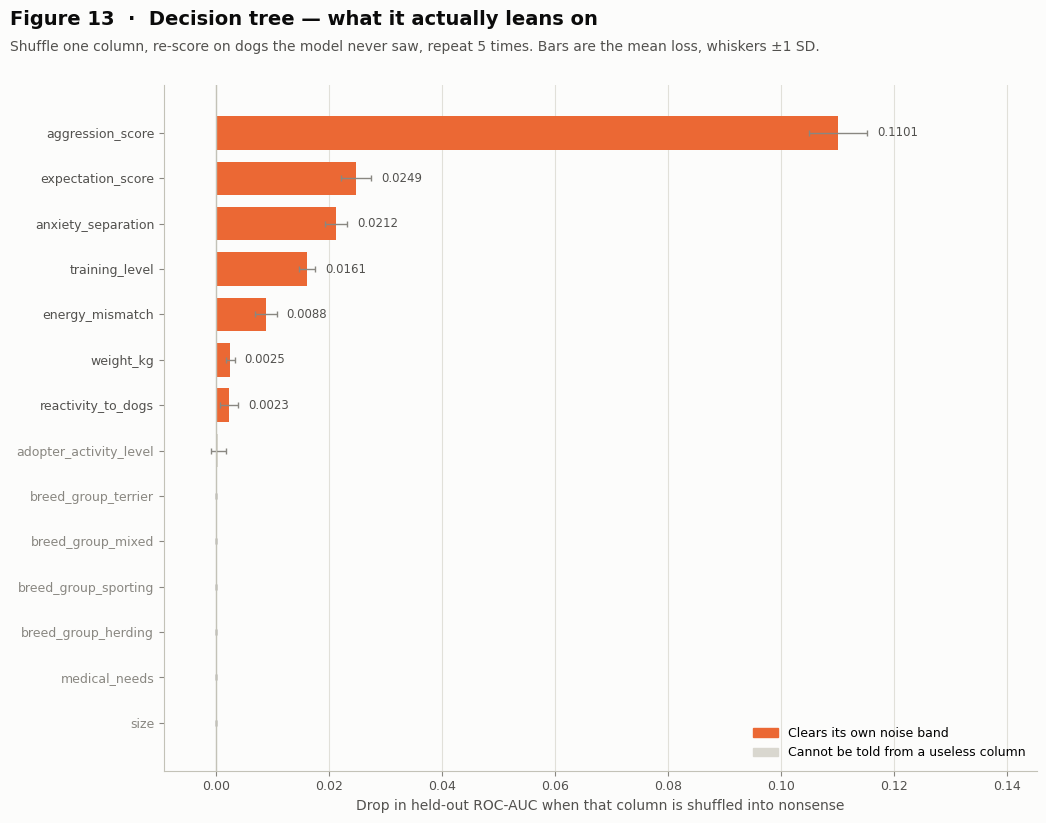

  Decision tree            ROC-AUC 0.7005 | PR-AUC 0.2753 | recall 0.337 | precision 0.316 | caught 530 of 1,574
  Random forest (reference) ROC-AUC 0.7478 | PR-AUC 0.3515 | recall 0.605 | precision 0.299 | caught 953 of 1,574
  saved figures/14_tree_scorecard.png


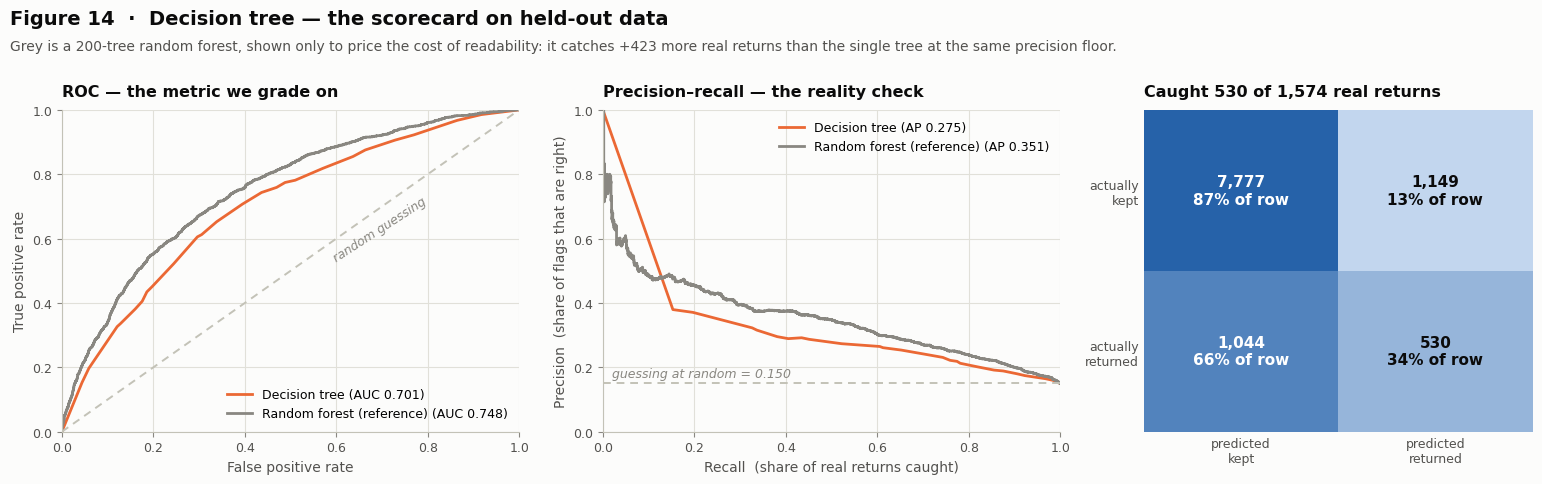

   [tree_rest: 42.2s]


In [ ]:
tic("tree_rest")

# --- SLOT 3: threshold ------------------------------------------------------
tree_cv_score = cv_scores(tree, X_tr_t, y_tr, folds)
tree_thr, tree_p, tree_r = tune_threshold(y_tr, tree_cv_score)
print(f"cut-off {tree_thr:.4f}  ->  CV precision {tree_p:.3f}, recall {tree_r:.3f}")
threshold_fig(12, "Decision tree", y_tr, tree_cv_score, tree_thr, "12_tree_threshold",
              note="class_weight='balanced' already pushes the tree's probabilities up, so "
                   "its cut-off lands much closer to 0.5 than k-NN's does.")

# --- SLOT 4: permutation importance ----------------------------------------
Xf_t, Xv_t, yf_t, yv_t = train_test_split(X_tr_t, y_tr, test_size=0.25,
                                          random_state=SEED, stratify=y_tr)
tree_inner = DecisionTreeClassifier(random_state=SEED, class_weight="balanced",
                                    ccp_alpha=best_alpha).fit(Xf_t, yf_t)
pi = permutation_importance(tree_inner, Xv_t, yv_t, scoring="roc_auc",
                            n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=N_JOBS)
tree_perm = pd.DataFrame({"mean": pi.importances_mean, "std": pi.importances_std},
                         index=FEATURES).sort_values("mean", ascending=False)
print(tree_perm.head(6).round(5).to_string())
perm_fig(13, "Decision tree", tree_perm, "13_tree_importance")

# --- SLOT 5: scorecard, with a random forest as the in-section comparison ----
rf = RandomForestClassifier(n_estimators=200 if FAST_MODE else 400, min_samples_leaf=5,
                            max_features="sqrt", class_weight="balanced_subsample",
                            n_jobs=N_JOBS, random_state=SEED).fit(X_tr_t, y_tr)
rf_cv_score = cv_scores(rf, X_tr_t, y_tr, folds)
rf_thr, _, _ = tune_threshold(y_tr, rf_cv_score)

tree_test = tree.predict_proba(X_te_t)[:, 1]
r_tree = evaluate("Decision tree", y_te, tree_test, tree_thr)
r_rf = evaluate("Random forest (reference)", y_te, rf.predict_proba(X_te_t)[:, 1],
                rf_thr, colour=MUTED, register=False)

gap = r_rf["tp"] - r_tree["tp"]
scorecard_fig(14, "Decision tree", y_te, r_tree, extra=r_rf, fname="14_tree_scorecard",
              note=f"Grey is a {rf.n_estimators}-tree random forest, shown only to price the "
                   f"cost of readability: it catches {gap:+,} more real returns than the "
                   f"single tree at the same precision floor.")

art["tree_perm"], art["tree_thr"], art["rf_result"] = tree_perm, tree_thr, r_rf
toc("tree_rest")

---
# Part 4 · Multilayer perceptron

**The idea in one sentence:** stack layers of simple units, each one taking a weighted sum of the layer below and bending it through a non-linear function, and let gradient descent tune every weight at once.

## What changed from the original perceptron, and why

The starting point for this section was a **single-layer `Perceptron`** — one linear unit. That model has three problems that no amount of tuning fixes:

1. **It can only draw a straight line.** One layer of weights means the decision boundary is a flat plane through the feature space. If risk depends on a *combination* — say, high energy is only a problem when the adopter is inactive — a single layer cannot express it. A hidden layer can.
2. **It produces no probabilities.** `Perceptron` has no `predict_proba`. It outputs a hard 0 or 1, which means no ROC curve, no threshold tuning, and no way to grade it on the same scale as anything else. (Its `decision_function` gives a ranking, which is what we use below to score it at all.)
3. **It never converges on data that is not linearly separable.** The perceptron learning rule only stops when it classifies every training row correctly. This data is nowhere near separable, so it just oscillates until `max_iter` runs out, and where it lands depends on the order the rows happened to arrive in.

An MLP fixes all three: hidden layers give it curved boundaries, a softmax output gives real probabilities, and it minimises a smooth loss by gradient descent so it converges to something stable.

**The original perceptron is kept and fitted anyway**, on exactly the same data, and appears in slot 5 as the comparison curve. The upgrade should be evidenced, not asserted.

## One constraint worth naming up front

`MLPClassifier` has **no `class_weight`, and its `fit` does not accept `sample_weight`.** There is no way to tell it the positive class matters more. The only lever for the 15% imbalance is where the threshold goes — exactly the same situation as k-NN, and the reason both sections lean on slot 3.

## 4.1 · Slot 1 — Tuning: architecture, then regularisation

Two sweeps rather than one grid. Two clean one-variable curves are far easier to read than a 16-cell heatmap, and the second sweep only matters at the architecture the first one picks.

**Note on early stopping.** sklearn's `early_stopping=True` holds out a validation slice and watches **accuracy** — which, on a target that is 85% one class, is the single least informative number available. It would happily stop the moment the network learned to predict "kept" for everything. So it is off here, and training instead stops when the *loss* stops improving. Loss responds to the minority class; accuracy does not.

⏱️ **The slowest cell in the notebook** — roughly 2–4 minutes.

In [ ]:
tic("mlp")


def make_mlp(hidden, alpha):
    """One place the network is defined, so every sweep compares like with like.

    early_stopping is deliberately OFF -- sklearn's version scores its internal
    validation slice on ACCURACY, which on a 15%-positive target is satisfied by
    predicting 'kept' forever. Training stops on the loss instead, which does
    respond to the rare class.
    """
    return MLPClassifier(
        hidden_layer_sizes=hidden, activation="relu", solver="adam", alpha=alpha,
        batch_size=256, learning_rate_init=1e-3, max_iter=300,
        early_stopping=False, n_iter_no_change=15, tol=1e-4, random_state=SEED)


if MLP_SUBSAMPLE and MLP_SUBSAMPLE < len(X_tr_s):
    sw = np.random.RandomState(SEED).choice(len(X_tr_s), MLP_SUBSAMPLE, replace=False)
    Xsw, ysw = X_tr_s.iloc[sw], y_tr[sw]
    print(f"sweeps run on a {len(sw):,}-row subsample (FAST_MODE); "
          f"the winner refits on all {len(X_tr_s):,}")
else:
    Xsw, ysw = X_tr_s, y_tr
    print(f"sweeps run on all {len(Xsw):,} training rows")

# --- sweep 1: how wide and how deep ----------------------------------------
ARCHS = [(32,), (64,), (64, 32), (128, 64)]
arch_scores = {}
for h in ARCHS:
    arch_scores[h] = cross_val_score(make_mlp(h, 1e-4), Xsw, ysw, cv=N_SPLITS,
                                     scoring="roc_auc", n_jobs=N_JOBS).mean()
    print(f"  hidden {str(h):<12} CV ROC-AUC = {arch_scores[h]:.4f}")
best_arch = max(arch_scores, key=arch_scores.get)

# --- sweep 2: how hard to penalise big weights ------------------------------
ALPHAS = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]   # runs past the turnover on purpose
alpha_scores = {}
print(f"\nnow sweeping the L2 penalty at hidden={best_arch}:")
for a in ALPHAS:
    alpha_scores[a] = cross_val_score(make_mlp(best_arch, a), Xsw, ysw, cv=N_SPLITS,
                                      scoring="roc_auc", n_jobs=N_JOBS).mean()
    print(f"  alpha {a:<8g} CV ROC-AUC = {alpha_scores[a]:.4f}")
best_alpha_mlp = max(alpha_scores, key=alpha_scores.get)

print(f"\nchosen: hidden={best_arch}, alpha={best_alpha_mlp:g}   "
      f"CV ROC-AUC = {alpha_scores[best_alpha_mlp]:.4f}")

mlp = make_mlp(best_arch, best_alpha_mlp).fit(X_tr_s, y_tr)
n_weights = sum(c.size for c in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
print(f"refit on all {len(X_tr_s):,} rows: stopped after {mlp.n_iter_} passes, "
      f"{n_weights:,} weights, final loss {mlp.loss_:.4f}")

art.update(arch_scores=arch_scores, alpha_scores=alpha_scores,
           best_arch=best_arch, best_alpha_mlp=best_alpha_mlp)
toc("mlp")

sweeps run on all 31,500 training rows
  hidden (32,)        CV ROC-AUC = 0.7084
  hidden (64,)        CV ROC-AUC = 0.6782
  hidden (64, 32)     CV ROC-AUC = 0.6272
  hidden (128, 64)    CV ROC-AUC = 0.6306

now sweeping the L2 penalty at hidden=(32,):
  alpha 0.0001   CV ROC-AUC = 0.7084
  alpha 0.001    CV ROC-AUC = 0.7064
  alpha 0.01     CV ROC-AUC = 0.7070
  alpha 0.1      CV ROC-AUC = 0.7207
  alpha 1        CV ROC-AUC = 0.7524
  alpha 10       CV ROC-AUC = 0.7522
  alpha 100      CV ROC-AUC = 0.7389

chosen: hidden=(32,), alpha=1   CV ROC-AUC = 0.7524
refit on all 31,500 rows: stopped after 63 passes, 1,313 weights, final loss 0.3709
   [mlp: 438.3s]


  saved figures/15_mlp_sweeps.png


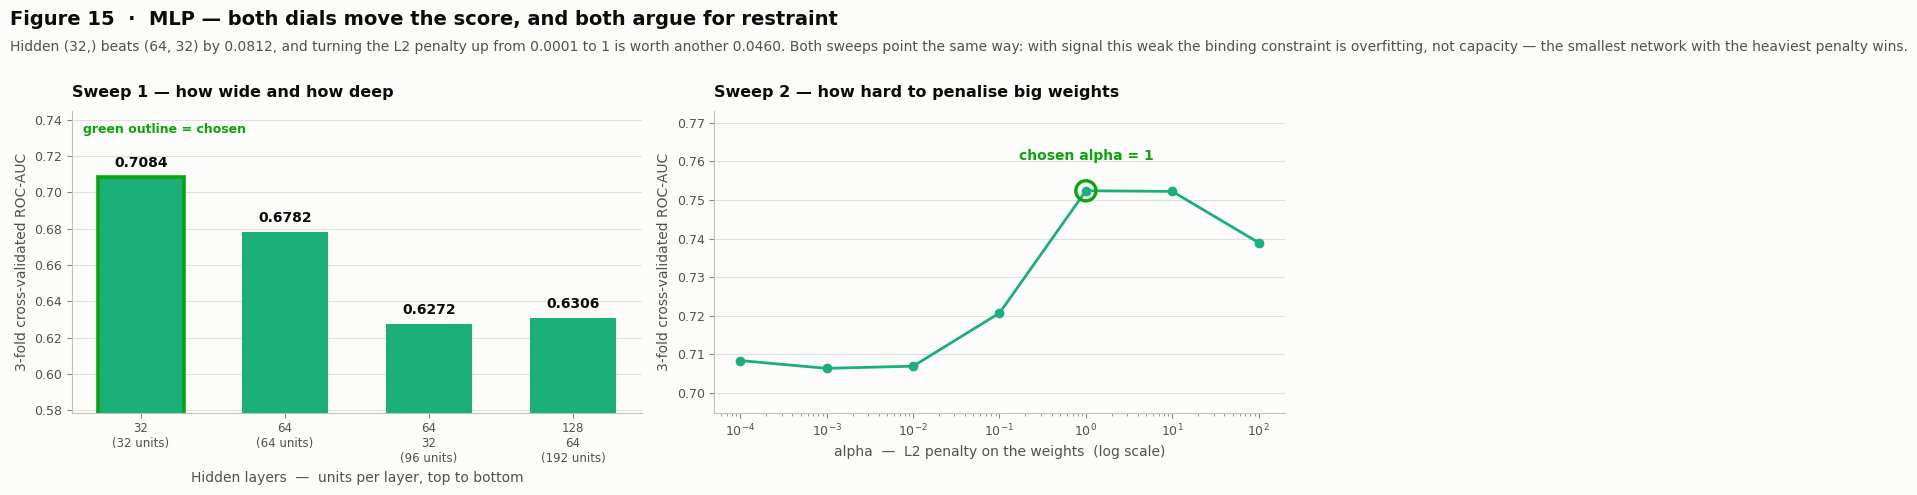

In [ ]:
# ===========================================================================
# FIGURE 15 -- SLOT 1: the two sweeps
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

ax = axes[0]
labels = ["\n".join(str(n) for n in h) for h in ARCHS]
vals = [arch_scores[h] for h in ARCHS]
bars = ax.bar(range(len(ARCHS)), vals, color=C_AQUA, width=0.6)
bars[ARCHS.index(best_arch)].set_edgecolor(C_GOOD)
bars[ARCHS.index(best_arch)].set_linewidth(2.6)
for i, v in enumerate(vals):
    ax.text(i, v + (max(vals) - min(vals)) * 0.05, f"{v:.4f}", ha="center",
            va="bottom", fontsize=10, color=INK, fontweight="bold")
ax.set_xticks(range(len(ARCHS)),
              [f"{lab}\n({sum(h)} units)" for lab, h in zip(labels, ARCHS)],
              fontsize=8.5)
lo, hi = min(vals), max(vals)
ax.set_ylim(lo - (hi - lo) * 0.6, hi + (hi - lo) * 0.45)
ax.set_xlabel("Hidden layers  —  units per layer, top to bottom")
ax.set_ylabel(f"{N_SPLITS}-fold cross-validated ROC-AUC")
ax.set_title("Sweep 1 — how wide and how deep")
ax.text(0.02, 0.96, "green outline = chosen", transform=ax.transAxes,
        fontsize=9, color=C_GOOD, va="top", fontweight="bold")
tidy(ax)

ax = axes[1]
avals = [alpha_scores[a] for a in ALPHAS]
ax.plot(ALPHAS, avals, color=C_AQUA, marker="o", markersize=6)
ax.scatter([best_alpha_mlp], [alpha_scores[best_alpha_mlp]], s=210,
           facecolors="none", edgecolors=C_GOOD, linewidths=2.4, zorder=5)
ax.annotate(f"chosen alpha = {best_alpha_mlp:g}", (best_alpha_mlp,
            alpha_scores[best_alpha_mlp]), xytext=(0, 22),
            textcoords="offset points", ha="center", fontsize=10,
            color=C_GOOD, fontweight="bold")
ax.set_xscale("log")
alo, ahi = min(avals), max(avals)
ax.set_ylim(alo - (ahi - alo) * 0.25, ahi + (ahi - alo) * 0.45)
ax.set_xlabel("alpha  —  L2 penalty on the weights  (log scale)")
ax.set_ylabel(f"{N_SPLITS}-fold cross-validated ROC-AUC")
ax.set_title("Sweep 2 — how hard to penalise big weights")
tidy(ax)

arch_spread = max(arch_scores.values()) - min(arch_scores.values())
alpha_spread = max(alpha_scores.values()) - min(alpha_scores.values())
worst_arch = min(arch_scores, key=arch_scores.get)
tail = (" Both sweeps point the same way: with signal this weak the binding constraint is "
        "overfitting, not capacity — the smallest network with the heaviest penalty wins."
        if best_arch == ARCHS[0] else
        " Capacity and regularisation are pulling against each other here, so both dials had "
        "to be set rather than either one alone.")
headline(fig, "Figure 15  ·  MLP — both dials move the score, and both argue for restraint",
         f"Hidden {best_arch} beats {worst_arch} by {arch_spread:.4f}, and turning the L2 "
         f"penalty up from {min(ALPHAS):g} to {best_alpha_mlp:g} is worth another "
         f"{alpha_spread:.4f}." + tail)
save(fig, "15_mlp_sweeps")
plt.show()

## 4.2 · Slot 2 — Mechanics: what the hidden layer buys

Three panels.

**Left — the network.** Every one of the 39 encoded columns feeds every unit in the first hidden layer, each connection carrying its own weight. Each unit adds up what it receives, adds a bias, and passes the result through ReLU (`max(0, x)`), which is where the non-linearity enters. Without it the whole stack would collapse algebraically into a single linear layer and the network would be no better than the perceptron it replaced.

**Middle — training.** The loss the network is actually minimising, one point per pass over the training data. Gradient descent takes a step downhill on every mini-batch of 256 rows.

**Right — the point of the whole exercise.** Both models fitted to the same two columns, with their predicted risk drawn as a surface. The perceptron can only cut the plane with a straight line. The MLP bends.

  saved figures/16_mlp_mechanics.png


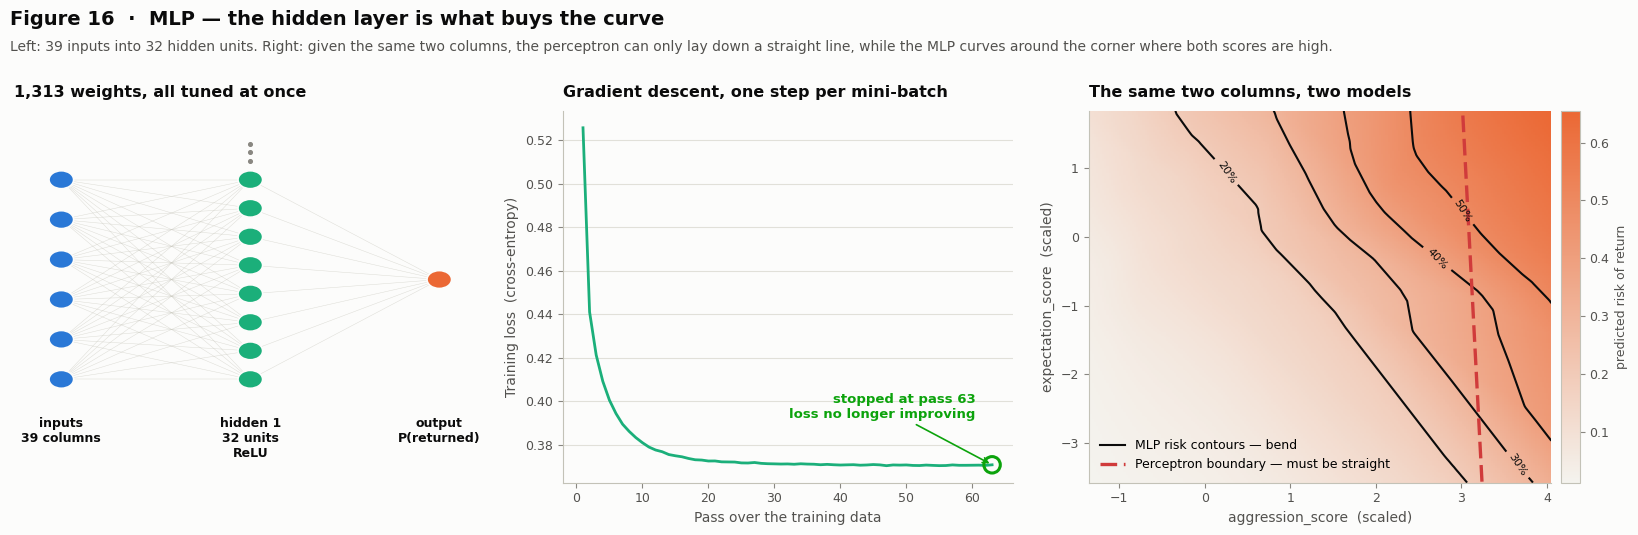

In [ ]:
# ===========================================================================
# FIGURE 16 -- SLOT 2: architecture, training, and what the hidden layer buys
# ===========================================================================
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4),
                         gridspec_kw={"width_ratios": [1.05, 1, 1.1]})

# --- panel 1: the network ---------------------------------------------------
ax = axes[0]
SHOWN_IN = 6                       # draw 6 of the 39 inputs, then an ellipsis
layer_sizes = [SHOWN_IN] + list(best_arch) + [1]
layer_draw = [min(n, 8) for n in layer_sizes]
layer_x = np.linspace(0.10, 0.90, len(layer_sizes))
node_pos = []
for xi, n_draw in zip(layer_x, layer_draw):
    ys = np.linspace(0.72, 0.14, n_draw) if n_draw > 1 else np.array([0.43])
    node_pos.append([(xi, yv) for yv in ys])

for left, right in zip(node_pos[:-1], node_pos[1:]):
    for (x0, y0) in left:
        for (x1, y1) in right:
            ax.plot([x0, x1], [y0, y1], color=BASELINE, lw=0.35, alpha=0.55,
                    zorder=1)
layer_cols = [C_BLUE] + [C_AQUA] * len(best_arch) + [C_ORANGE]
for (pts, col) in zip(node_pos, layer_cols):
    for (x0, y0) in pts:
        ax.add_patch(Circle((x0, y0), 0.026, facecolor=col, edgecolor=SURFACE,
                            linewidth=1.2, zorder=3))
names = [f"inputs\n{len(FEATURES)} columns"] + \
        [f"hidden {i + 1}\n{n} units\nReLU" for i, n in enumerate(best_arch)] + \
        ["output\nP(returned)"]
for xi, lab, col in zip(layer_x, names, layer_cols):
    ax.text(xi, 0.03, lab, ha="center", va="top", fontsize=9, color=INK,
            fontweight="bold")
for xi, n_true, n_drawn in zip(layer_x, layer_sizes, layer_draw):
    if n_true > n_drawn:
        # three plotted dots, not a "vertical ellipsis" character: Helvetica Neue
        # has no U+22EE and matplotlib renders the miss as a tofu box
        ax.scatter([xi] * 3, [0.775, 0.800, 0.825], s=7, color=MUTED, zorder=3)
ax.set_xlim(0, 1)
ax.set_ylim(-0.16, 0.92)
ax.set_axis_off()
ax.set_title(f"{n_weights:,} weights, all tuned at once", loc="left")

# --- panel 2: the training curve --------------------------------------------
ax = axes[1]
ax.plot(np.arange(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_, color=C_AQUA)
ax.scatter([len(mlp.loss_curve_)], [mlp.loss_curve_[-1]], s=140,
           facecolors="none", edgecolors=C_GOOD, linewidths=2.2, zorder=5)
ax.annotate(f"stopped at pass {mlp.n_iter_}\nloss no longer improving",
            (len(mlp.loss_curve_), mlp.loss_curve_[-1]), xytext=(-12, 34),
            textcoords="offset points", ha="right", fontsize=9.5, color=C_GOOD,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=C_GOOD, lw=1.2))
ax.set_xlabel("Pass over the training data")
ax.set_ylabel("Training loss  (cross-entropy)")
ax.set_title("Gradient descent, one step per mini-batch")
tidy(ax)

# --- panel 3: straight line vs curve ----------------------------------------
# Both models refitted on just two columns so the boundary can be drawn. This
# panel is an illustration of the mechanism, not a scored model.
ax = axes[2]
PAIR = ["aggression_score", "expectation_score"]
X2 = X_tr_s[PAIR].to_numpy()
p2 = Perceptron(max_iter=1000, eta0=0.1, random_state=SEED,
                class_weight="balanced").fit(X2, y_tr)
m2 = make_mlp((32, 16), 1e-3).fit(X2, y_tr)

gx, gy = np.meshgrid(np.linspace(X2[:, 0].min(), X2[:, 0].max(), 220),
                     np.linspace(X2[:, 1].min(), X2[:, 1].max(), 220))
grid = np.c_[gx.ravel(), gy.ravel()]
zz = m2.predict_proba(grid)[:, 1].reshape(gx.shape)

# Sequential, not diverging: predicted risk runs from low to high with no
# meaningful midpoint, and a diverging ramp would invent one. Pale to orange
# keeps the notebook-wide "orange means returned" reading.
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "risk", ["#f4f3ee", RETURNED])
im = ax.pcolormesh(gx, gy, zz, cmap=cmap, shading="auto",
                   vmin=float(zz.min()), vmax=float(zz.max()))
# Several fixed risk levels rather than one arbitrary line: the family of
# contours is what shows the curvature, and each is a stated probability.
levels = [lv for lv in (0.2, 0.3, 0.4, 0.5) if zz.min() < lv < zz.max()]
cs = ax.contour(gx, gy, zz, levels=levels, colors=[INK], linewidths=1.5)
ax.clabel(cs, fmt=lambda v: f"{v:.0%}", fontsize=8, inline=True)
# the perceptron's boundary is w . x + b = 0 -- a straight line, by construction
w, b = p2.coef_[0], p2.intercept_[0]
xs = np.array([X2[:, 0].min(), X2[:, 0].max()])
ax.plot(xs, -(w[0] * xs + b) / w[1], color=C_CRIT, lw=2.4, ls=(0, (5, 2)))
ax.set_xlim(X2[:, 0].min(), X2[:, 0].max())
ax.set_ylim(X2[:, 1].min(), X2[:, 1].max())
ax.set_xlabel(f"{PAIR[0]}  (scaled)")
ax.set_ylabel(f"{PAIR[1]}  (scaled)")
ax.set_title("The same two columns, two models")
ax.legend(handles=[
    Line2D([], [], color=INK, lw=1.5, label="MLP risk contours — bend"),
    Line2D([], [], color=C_CRIT, lw=2.4, ls=(0, (5, 2)),
           label="Perceptron boundary — must be straight"),
], loc="lower left")
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
cb.set_label("predicted risk of return", fontsize=9)
tidy(ax, grid_axis=None)

headline(fig, "Figure 16  ·  MLP — the hidden layer is what buys the curve",
         f"Left: {len(FEATURES)} inputs into {' then '.join(str(n) for n in best_arch)} hidden "
         f"units. Right: given the same two columns, the perceptron can only lay down a straight "
         "line, while the MLP curves around the corner where both scores are high.")
save(fig, "16_mlp_mechanics")
plt.show()

## 4.3 · Slots 3, 4 and 5 — threshold, importance, scorecard

Slot 4 matters more here than anywhere else in the notebook. A tree can be read; a neighbour search can be inspected; a network of several thousand weights cannot be interpreted by looking at it. Permutation importance is the only way to find out what this model is using, and it works on the MLP exactly as it did on the other three.

Slot 5 carries the **original single-layer perceptron** as the comparison curve, fitted on identical data. It has no `predict_proba`, so its curve comes from `decision_function` — a ranking, which is all ROC needs.

cut-off 0.1786  ->  CV precision 0.300, recall 0.621
  saved figures/17_mlp_threshold.png


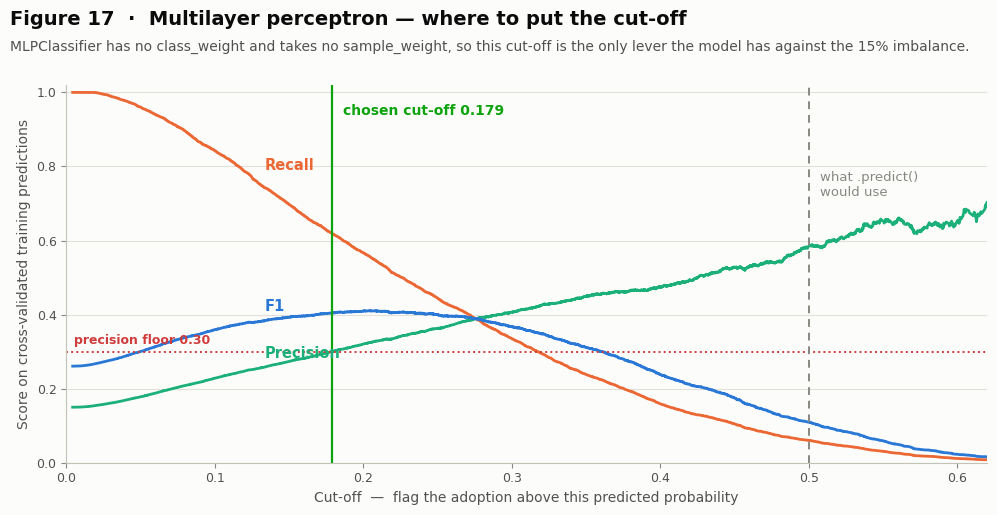

                       mean      std
aggression_score    0.07597  0.00299
anxiety_separation  0.02569  0.00186
expectation_score   0.02131  0.00110
energy_mismatch     0.01954  0.00212
training_level      0.01953  0.00268
reactivity_to_dogs  0.01642  0.00239
  saved figures/18_mlp_importance.png


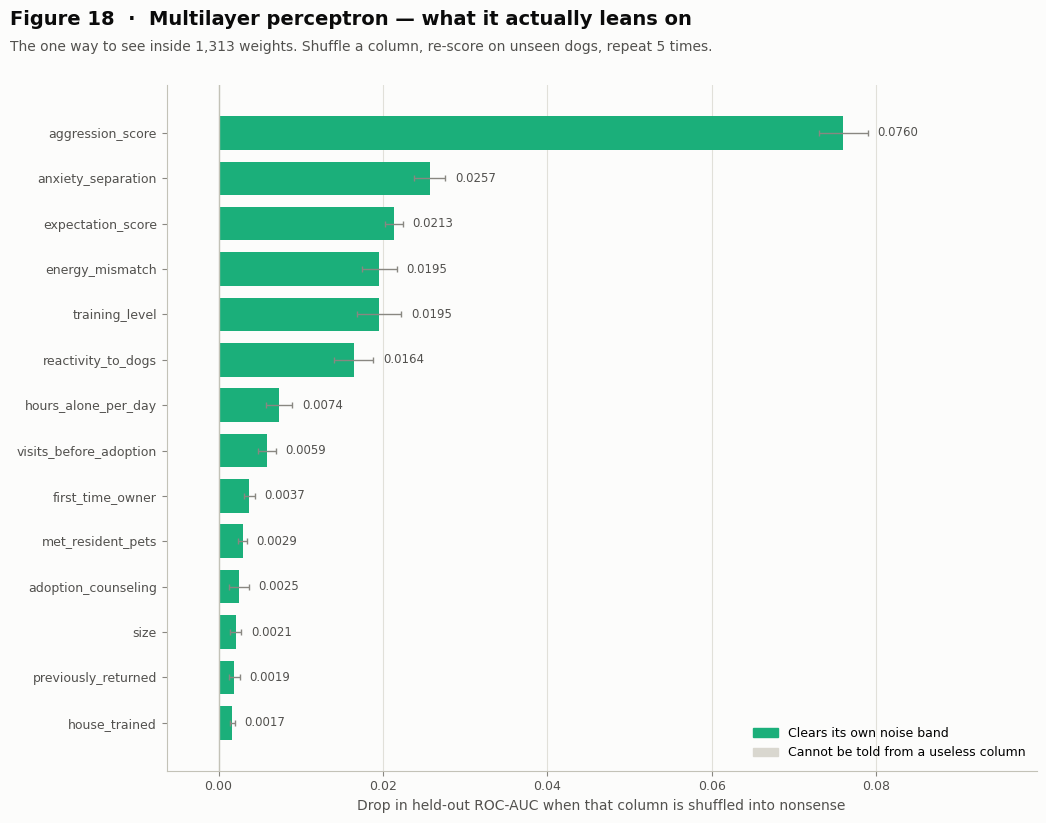

  Multilayer perceptron    ROC-AUC 0.7626 | PR-AUC 0.3804 | recall 0.638 | precision 0.312 | caught 1,004 of 1,574
  Single-layer perceptron  ROC-AUC 0.6169 | PR-AUC 0.2213 | recall 0.120 | precision 0.276 | caught 189 of 1,574
  saved figures/19_mlp_scorecard.png


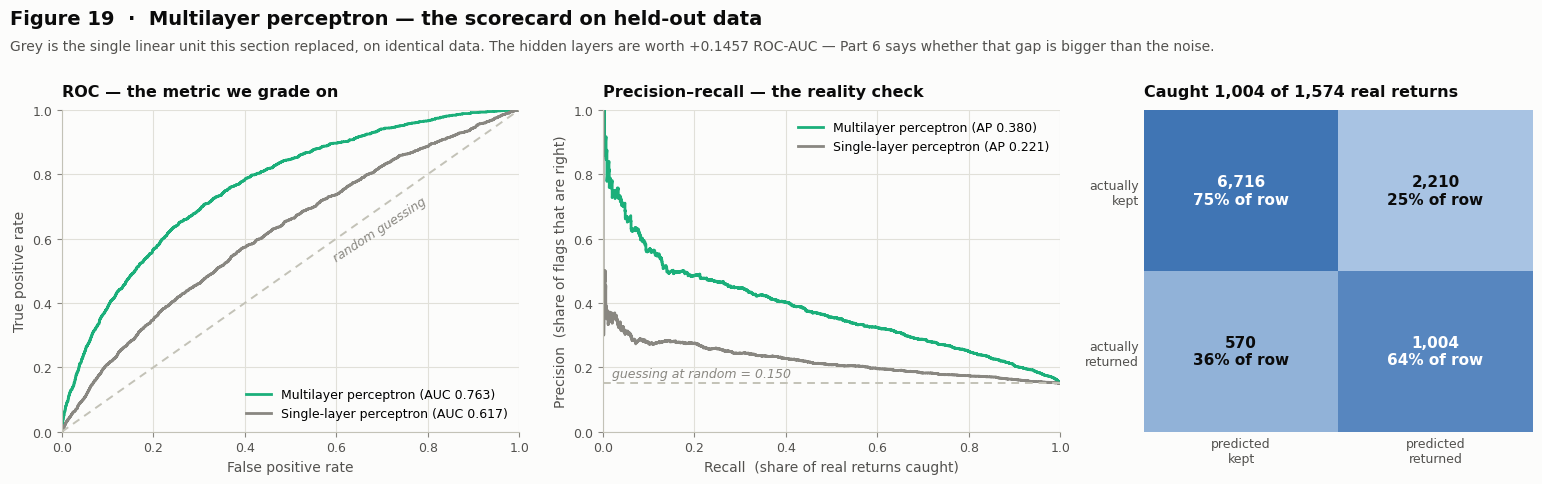

   [mlp_rest: 20.5s]


In [ ]:
tic("mlp_rest")

# --- SLOT 3: threshold ------------------------------------------------------
mlp_cv_score = cv_scores(mlp, X_tr_s, y_tr, folds)
mlp_thr, mlp_p, mlp_r = tune_threshold(y_tr, mlp_cv_score)
print(f"cut-off {mlp_thr:.4f}  ->  CV precision {mlp_p:.3f}, recall {mlp_r:.3f}")
threshold_fig(17, "Multilayer perceptron", y_tr, mlp_cv_score, mlp_thr,
              "17_mlp_threshold",
              note="MLPClassifier has no class_weight and takes no sample_weight, so this "
                   "cut-off is the only lever the model has against the 15% imbalance.")

# --- SLOT 4: permutation importance ----------------------------------------
mlp_inner = make_mlp(best_arch, best_alpha_mlp).fit(Xf, yf)
pi = permutation_importance(mlp_inner, Xv, yv, scoring="roc_auc",
                            n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=N_JOBS)
mlp_perm = pd.DataFrame({"mean": pi.importances_mean, "std": pi.importances_std},
                        index=FEATURES).sort_values("mean", ascending=False)
print(mlp_perm.head(6).round(5).to_string())
perm_fig(18, "Multilayer perceptron", mlp_perm, "18_mlp_importance",
         note=f"The one way to see inside {n_weights:,} weights. Shuffle a column, re-score "
              f"on unseen dogs, repeat {PERM_REPEATS} times.")

# --- SLOT 5: scorecard, against the perceptron it replaced ------------------
# The original model, fitted on identical data. It has no predict_proba, so its
# decision_function supplies the ranking -- which is all a ROC curve needs.
perc = Perceptron(max_iter=1000, eta0=0.1, random_state=SEED,
                  class_weight="balanced").fit(X_tr_s, y_tr)
perc_cv = cv_scores(perc, X_tr_s, y_tr, folds, method="decision_function")
perc_thr, _, _ = tune_threshold(y_tr, perc_cv)

mlp_test = mlp.predict_proba(X_te_s)[:, 1]
r_mlp = evaluate("Multilayer perceptron", y_te, mlp_test, mlp_thr)
r_perc = evaluate("Single-layer perceptron", y_te, perc.decision_function(X_te_s),
                  perc_thr, colour=MUTED, register=False)

lift = r_mlp["roc_auc"] - r_perc["roc_auc"]
scorecard_fig(19, "Multilayer perceptron", y_te, r_mlp, extra=r_perc,
              fname="19_mlp_scorecard",
              note=f"Grey is the single linear unit this section replaced, on identical data. "
                   f"The hidden layers are worth {lift:+.4f} ROC-AUC — Part 6 says whether "
                   "that gap is bigger than the noise.")

art["mlp_perm"], art["mlp_thr"], art["perc_result"] = mlp_perm, mlp_thr, r_perc
toc("mlp_rest")

---
# Part 5 · Nearest centroid

**The idea in one sentence:** work out the average kept dog and the average returned dog, then classify a new adoption by whichever average it sits closer to.

It is the simplest model in the notebook by a wide margin. Training is two calls to `mean()`. That simplicity is the point of including it — it sets the floor that the other three have to clear to justify their complexity.

## What was wrong with the original, and what each fix does

The starting version of this model had five defects. They are worth going through individually, because only one of them is about accuracy — the rest are about being able to *measure* it at all.

**1. It could not produce a ROC curve.** `NearestCentroid` exposes `.predict()` and nothing else — no `predict_proba`, no `decision_function`. It hands back a hard 0 or 1 and keeps the distances it computed to itself. That makes it impossible to rank predictions, so it could not be graded on the same scale as any other model here. **This is the blocking defect**, and everything else follows from fixing it.

The fix is a thin wrapper that exposes the number the model has already computed:

> `score(x) = distance(x, kept centroid) − distance(x, returned centroid)`

Positive means closer to the returned centroid. Thresholding that at zero reproduces sklearn's own rule exactly — the wrapper does not change the model, it just stops the model from hiding its own arithmetic.

**2. Only the numeric columns were scaled.** The original ran `StandardScaler` on the numerics and let the one-hot dummies through as raw 0/1. For a model whose entire mechanism is Euclidean distance, that is a real bug: a dummy has a standard deviation around 0.36 against 1.0 for a scaled numeric, so every categorical silently contributed about a third of its fair share. Part 1's `make_matrix(scale=True)` scales the whole matrix. Slot 5 measures what the bug cost, and the answer is more interesting than "a lot" — see the note after Figure 24.

**3. The cut-off was never moved.** "Closer centroid wins" is a threshold at exactly zero, which quietly assumes the two classes are equally common and equally spread. Neither holds here. With a score exposed, slot 3 tunes it like every other model.

**4. `shrink_threshold` was never touched.** This is *nearest shrunken centroids* — pull each feature's two centroids toward the overall mean, and any feature whose classes are not far enough apart collapses to no contribution at all. It is this model's built-in feature selection, it was sitting unused at `None`, and slot 1 now tunes it.

**5. It used an arbitrary 22-column list, a different test fraction, and no cross-validation.** All three are gone — this section reads the same `X_tr_s` / `X_te_s`, the same 25% split, and the same folds as the other three models.

## 5.0 · The wrapper

In [ ]:
class ScoredNearestCentroid(ClassifierMixin, BaseEstimator):
    """NearestCentroid that exposes the number it has already computed.

    sklearn's NearestCentroid has predict() and nothing else -- no
    decision_function and no predict_proba -- so it cannot be placed on a ROC
    curve beside the other three models. It is not that the information is
    missing; predict() computes both distances and then throws away everything
    except which one was smaller.

    The score is the signed distance gap

        score(x) = ||x - c_kept|| - ||x - c_returned||

    which is positive when x sits closer to the returned centroid. Thresholding
    it at zero reproduces sklearn's own decision rule exactly, so this wrapper
    changes nothing about the model -- it only makes the decision rankable, and
    therefore gradeable and tunable.
    """

    def __init__(self, shrink_threshold=None):
        self.shrink_threshold = shrink_threshold

    def fit(self, X, y):
        self.nc_ = NearestCentroid(shrink_threshold=self.shrink_threshold)
        self.nc_.fit(np.asarray(X, dtype=float), np.asarray(y))
        self.classes_ = self.nc_.classes_
        self.centroids_ = self.nc_.centroids_
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        # (n_samples, n_classes) matrix of distances to each centroid
        d = np.linalg.norm(X[:, None, :] - self.centroids_[None, :, :], axis=2)
        return d[:, 0] - d[:, 1]

    def predict(self, X):
        return self.classes_[(self.decision_function(X) >= 0).astype(int)]


# Proof that the wrapper is faithful: its predictions must match sklearn's own.
_check_nc = NearestCentroid().fit(X_tr_s, y_tr)
_check_ours = ScoredNearestCentroid().fit(X_tr_s, y_tr)
_agree = (_check_nc.predict(X_te_s) == _check_ours.predict(X_te_s)).mean()
print(f"wrapper agrees with sklearn's NearestCentroid on {_agree:.2%} of test rows")
assert _agree == 1.0, "the wrapper changed the model -- it must not"

print(f"and it can now be scored: ROC-AUC = "
      f"{roc_auc_score(y_te, _check_ours.decision_function(X_te_s)):.4f}   "
      f"(sklearn's own NearestCentroid cannot produce this number at all)")

wrapper agrees with sklearn's NearestCentroid on 100.00% of test rows
and it can now be scored: ROC-AUC = 0.7533   (sklearn's own NearestCentroid cannot produce this number at all)


## 5.1 · Slot 1 — Tuning: how hard to shrink

`shrink_threshold` is the only hyperparameter this model has, and the original code left it at `None`.

What it does: each feature's two class centroids are pulled toward the overall mean by the threshold amount, in units of that feature's within-class spread. Any feature whose classes are closer together than the threshold collapses onto the overall mean — from which point it contributes *identically* to both distances and therefore drops out of the decision entirely.

That makes it genuine embedded feature selection, and it is the direct analogue of the tree's pruning fee: one dial that trades detail against noise, chosen by cross-validation.

Fast — the whole sweep is a few seconds, because fitting is two averages.

In [ ]:
tic("nc")
SHRINKS = np.round(np.linspace(0.0, 2.0, 15), 4)

nc_curve, nc_alive = {}, {}
for s_ in SHRINKS:
    est = ScoredNearestCentroid(shrink_threshold=None if s_ == 0 else float(s_))
    nc_curve[s_] = cross_val_score(est, X_tr_s, y_tr, cv=folds,
                                   scoring="roc_auc", n_jobs=N_JOBS).mean()
    # a feature is "alive" only while its two centroids still differ
    c = est.fit(X_tr_s, y_tr).centroids_
    nc_alive[s_] = int((np.abs(c[0] - c[1]) > 1e-12).sum())

best_shrink = max(nc_curve, key=nc_curve.get)
for s_ in SHRINKS:
    mark = "  <-- chosen" if s_ == best_shrink else ""
    print(f"  shrink {s_:<6.4f}  CV ROC-AUC {nc_curve[s_]:.4f}   "
          f"{nc_alive[s_]:>2}/{len(FEATURES)} columns still contributing{mark}")

nc_core = ScoredNearestCentroid(
    shrink_threshold=None if best_shrink == 0 else float(best_shrink))

# Calibration turns the distance gap into a genuine probability, so slot 3 works
# in the same units as the other three sections. ROC-AUC is invariant to any
# monotone transform, so this CANNOT change the ranking or the AUC -- it is for
# comparability, not for performance.
nc = CalibratedClassifierCV(nc_core, method="sigmoid", cv=3).fit(X_tr_s, y_tr)

nc_raw = clone(nc_core).fit(X_tr_s, y_tr)
print(f"\nchosen shrink_threshold = {best_shrink:g}   CV ROC-AUC = {nc_curve[best_shrink]:.4f}")
print(f"columns still contributing: {nc_alive[best_shrink]} of {len(FEATURES)}")
print(f"AUC from raw distance gap  : {roc_auc_score(y_te, nc_raw.decision_function(X_te_s)):.4f}")
print(f"AUC after calibration      : {roc_auc_score(y_te, nc.predict_proba(X_te_s)[:, 1]):.4f}"
      "   (identical, as it must be)")

art.update(nc_curve=nc_curve, nc_alive=nc_alive, best_shrink=best_shrink)
toc("nc")

  shrink 0.0000  CV ROC-AUC 0.7476   39/39 columns still contributing
  shrink 0.1429  CV ROC-AUC 0.7480   38/39 columns still contributing
  shrink 0.2857  CV ROC-AUC 0.7483   35/39 columns still contributing
  shrink 0.4286  CV ROC-AUC 0.7485   30/39 columns still contributing
  shrink 0.5714  CV ROC-AUC 0.7486   27/39 columns still contributing  <-- chosen
  shrink 0.7143  CV ROC-AUC 0.7486   27/39 columns still contributing
  shrink 0.8571  CV ROC-AUC 0.7485   26/39 columns still contributing
  shrink 1.0000  CV ROC-AUC 0.7483   24/39 columns still contributing
  shrink 1.1429  CV ROC-AUC 0.7480   23/39 columns still contributing
  shrink 1.2857  CV ROC-AUC 0.7476   23/39 columns still contributing
  shrink 1.4286  CV ROC-AUC 0.7470   22/39 columns still contributing
  shrink 1.5714  CV ROC-AUC 0.7464   21/39 columns still contributing
  shrink 1.7143  CV ROC-AUC 0.7456   21/39 columns still contributing
  shrink 1.8571  CV ROC-AUC 0.7448   21/39 columns still contributing
  shrink

  saved figures/20_nc_shrinkage.png


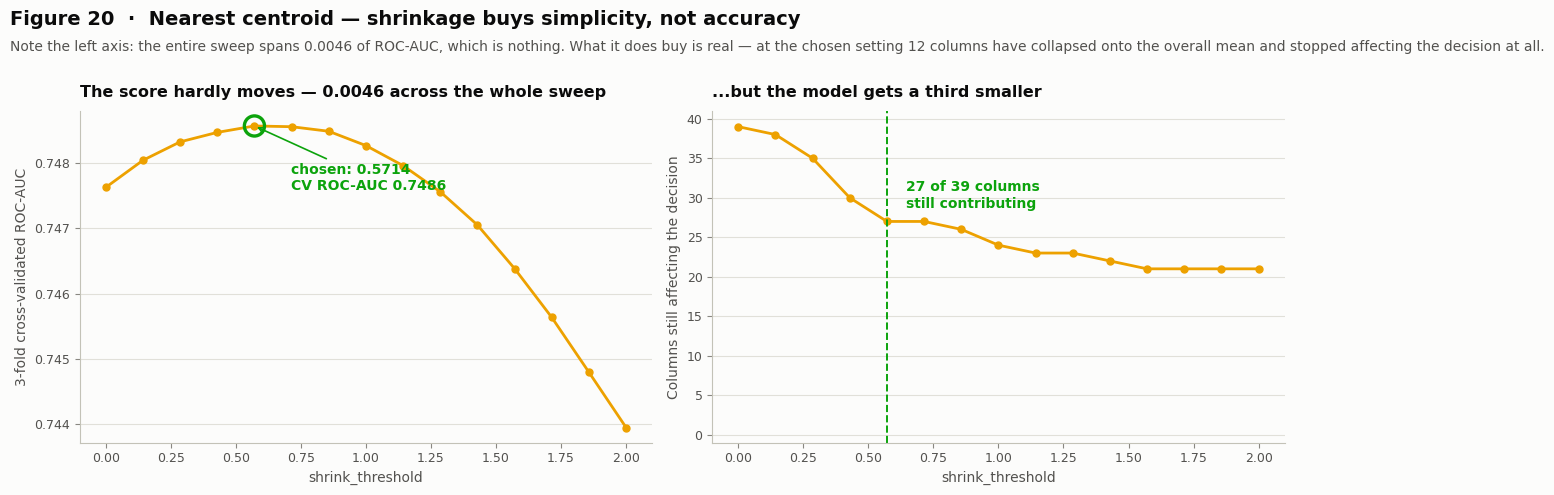

In [ ]:
# ===========================================================================
# FIGURE 20 -- SLOT 1: the shrinkage path
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharex=True)
xs = list(SHRINKS)

ax = axes[0]
ax.plot(xs, [nc_curve[s_] for s_ in xs], color=C_YELLOW, marker="o", markersize=5)
ax.scatter([best_shrink], [nc_curve[best_shrink]], s=210, facecolors="none",
           edgecolors=C_GOOD, linewidths=2.4, zorder=5)
ax.annotate(f"chosen: {best_shrink:g}\nCV ROC-AUC {nc_curve[best_shrink]:.4f}",
            (best_shrink, nc_curve[best_shrink]), xytext=(26, -46),
            textcoords="offset points", fontsize=10, color=C_GOOD, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=C_GOOD, lw=1.2))
ax.set_ylabel(f"{N_SPLITS}-fold cross-validated ROC-AUC")
ax.set_xlabel("shrink_threshold")
nc_span = max(nc_curve.values()) - min(nc_curve.values())
ax.set_title(f"The score hardly moves — {nc_span:.4f} across the whole sweep")
tidy(ax)

ax = axes[1]
ax.plot(xs, [nc_alive[s_] for s_ in xs], color=C_YELLOW, marker="o", markersize=5)
ax.axvline(best_shrink, color=C_GOOD, ls="--", lw=1.4)
ax.annotate(f"{nc_alive[best_shrink]} of {len(FEATURES)} columns\nstill contributing",
            (best_shrink, nc_alive[best_shrink]), xytext=(14, 10),
            textcoords="offset points", fontsize=10, color=C_GOOD, fontweight="bold")
ax.set_ylim(-1, len(FEATURES) + 2)
ax.set_ylabel("Columns still affecting the decision")
ax.set_xlabel("shrink_threshold")
ax.set_title("...but the model gets a third smaller")
tidy(ax)

headline(fig, "Figure 20  ·  Nearest centroid — shrinkage buys simplicity, not accuracy",
         f"Note the left axis: the entire sweep spans {nc_span:.4f} of ROC-AUC, which is "
         f"nothing. What it does buy is real — at the chosen setting {len(FEATURES) - nc_alive[best_shrink]} "
         "columns have collapsed onto the overall mean and stopped affecting the decision at all.")
save(fig, "20_nc_shrinkage")
plt.show()

## 5.2 · Slot 2 — Mechanics: the whole model, drawn

This model is simple enough to show completely, which no other section can claim.

**Left — the two centroids.** One dot per class per column, in scaled units, so the gap between the dots *is* the model. Every column where the dots sit on top of each other contributes nothing but noise to the distance. Every column where they separate is doing work.

**Right — what that produces.** The signed distance gap for the training data, split by what actually happened. The overlap between the two humps is the model's ceiling, drawn directly.

The dashed line at zero is the rule the original code used: closer centroid wins. It sits far to the right of where it should be, and the reason is visible in the picture — the kept hump has almost six times as many dogs in it, so a cut-off placed by geometry alone ignores which class was more likely in the first place.

  saved figures/21_nc_centroids.png


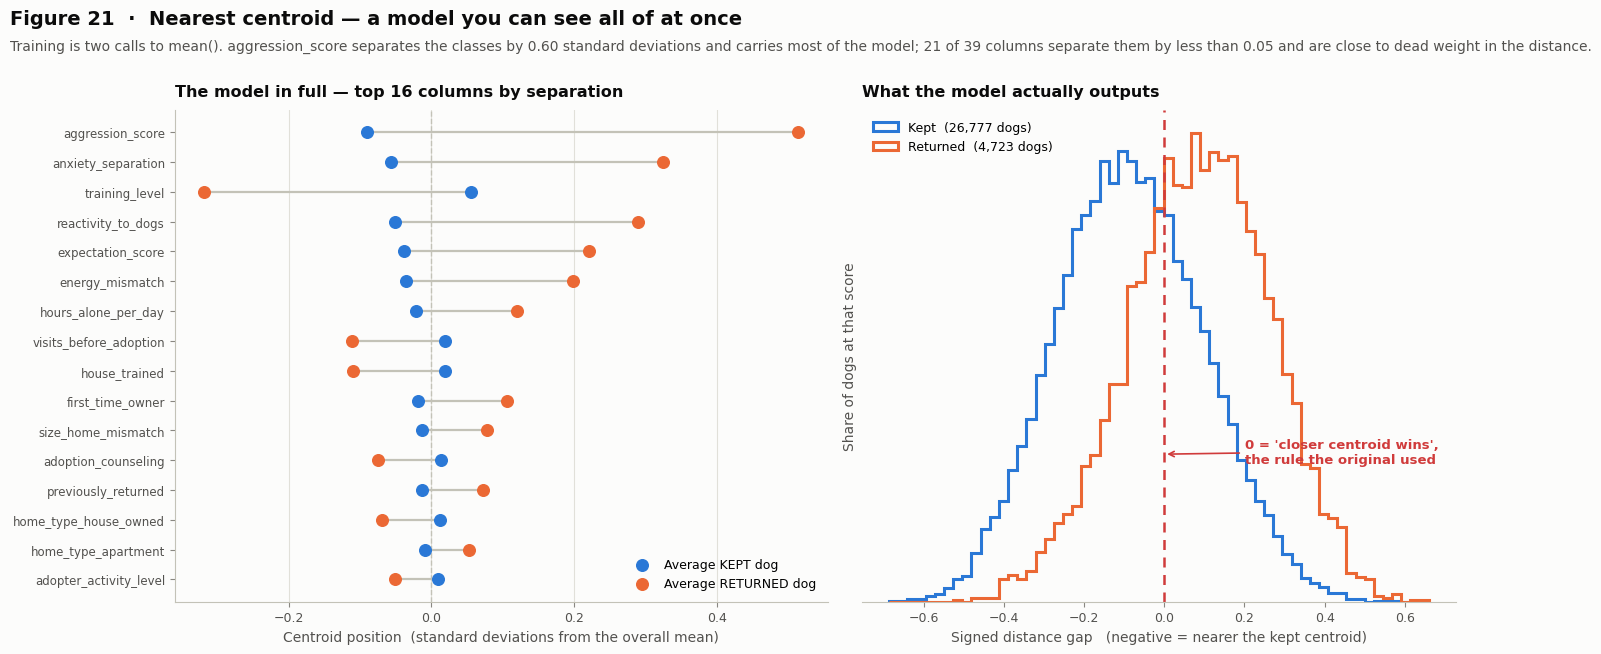

In [ ]:
# ===========================================================================
# FIGURE 21 -- SLOT 2: the entire model, in two panels
# ===========================================================================
cent = nc_raw.centroids_
gap = pd.Series(cent[1] - cent[0], index=FEATURES)
order = gap.abs().sort_values(ascending=False).head(16).index[::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.6),
                         gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0]
ypos = np.arange(len(order))
for i, c in enumerate(order):
    k_, r_ = cent[0][FEATURES.index(c)], cent[1][FEATURES.index(c)]
    ax.plot([k_, r_], [i, i], color=BASELINE, lw=1.6, zorder=1)
ax.scatter([cent[0][FEATURES.index(c)] for c in order], ypos, s=70, color=KEPT,
           zorder=3, label="Average KEPT dog")
ax.scatter([cent[1][FEATURES.index(c)] for c in order], ypos, s=70, color=RETURNED,
           zorder=3, label="Average RETURNED dog")
ax.set_yticks(ypos, list(order), fontsize=8.5)
ax.axvline(0, color=BASELINE, lw=1.0, ls="--")
ax.set_xlabel("Centroid position  (standard deviations from the overall mean)")
ax.set_title(f"The model in full — top {len(order)} columns by separation")
ax.legend(loc="lower right")
tidy(ax, grid_axis="x")

ax = axes[1]
sc_tr = nc_raw.decision_function(X_tr_s)
bins = np.linspace(sc_tr.min(), sc_tr.max(), 60)
ax.hist(sc_tr[y_tr == 0], bins=bins, density=True, histtype="step", linewidth=2.2,
        color=KEPT, label=f"Kept  ({(y_tr == 0).sum():,} dogs)")
ax.hist(sc_tr[y_tr == 1], bins=bins, density=True, histtype="step", linewidth=2.2,
        color=RETURNED, label=f"Returned  ({(y_tr == 1).sum():,} dogs)")
ax.axvline(0, color=C_CRIT, lw=1.8, ls=(0, (4, 3)))
# Anchored well down the line and pulled out to the right: both humps peak near
# zero, so anything placed at the top of the axis lands on top of the data.
ax.annotate("0 = 'closer centroid wins',\nthe rule the original used",
            xy=(0, ax.get_ylim()[1] * 0.30), xytext=(58, -6),
            textcoords="offset points", fontsize=9.5, color=C_CRIT,
            fontweight="bold", ha="left",
            arrowprops=dict(arrowstyle="->", color=C_CRIT, lw=1.2))
ax.set_xlabel("Signed distance gap   (negative = nearer the kept centroid)")
ax.set_ylabel("Share of dogs at that score")
ax.set_yticks([])
ax.set_title("What the model actually outputs")
ax.legend(loc="upper left")
tidy(ax, grid_axis=None)
ax.spines["left"].set_visible(False)

top_gap = gap.abs().sort_values(ascending=False)
dead = int((gap.abs() < 0.05).sum())
headline(fig, "Figure 21  ·  Nearest centroid — a model you can see all of at once",
         f"Training is two calls to mean(). {top_gap.index[0]} separates the classes by "
         f"{top_gap.iloc[0]:.2f} standard deviations and carries most of the model; "
         f"{dead} of {len(FEATURES)} columns separate them by less than 0.05 and are close to "
         "dead weight in the distance.")
save(fig, "21_nc_centroids")
plt.show()

## 5.3 · Slots 3, 4 and 5 — threshold, importance, scorecard

Slot 5 is where the repair gets priced. It carries the **original pipeline** as the comparison curve: dummies left unscaled, no shrinkage, and the cut-off left at the centroid midpoint.

That comparison is only possible *because* of fix 1. The original code could not be drawn on a ROC axis at all — it reported a single accuracy number, 0.68, against a do-nothing baseline of 0.85, which made it look worse than useless while saying nothing about whether it ranked dogs sensibly. Both versions here are run through the same wrapper so the curves exist; what differs between them is only the scaling and the tuning.

The two fixes separate cleanly across the figure, which is worth knowing before reading it. **ROC-AUC is threshold-free**, so the gap between the two *curves* is the scaling fix on its own. The **confusion matrix** is where the threshold fix shows up. They do not point the same way, and the note underneath says so plainly.

cut-off 0.1797  ->  CV precision 0.300, recall 0.599
  saved figures/22_nc_threshold.png


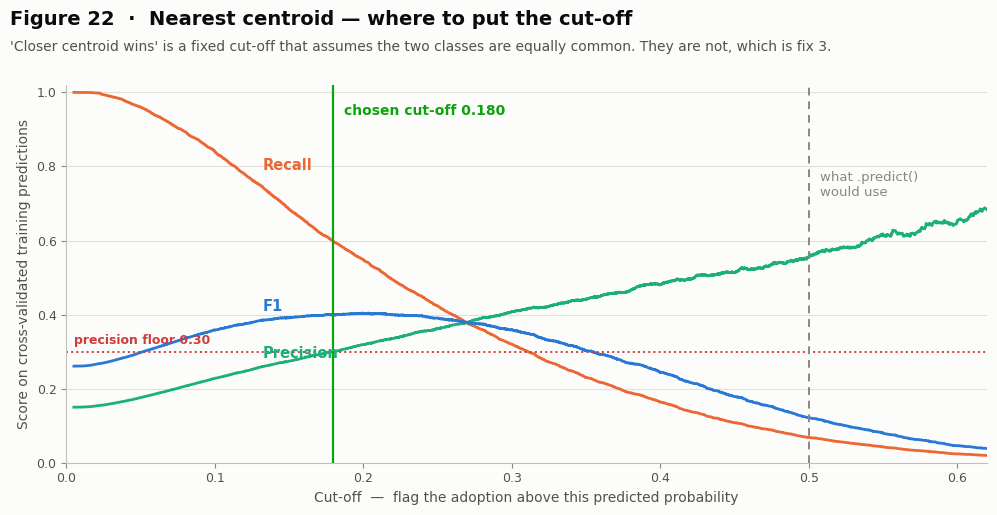

                       mean      std
aggression_score    0.07259  0.00255
anxiety_separation  0.02664  0.00250
reactivity_to_dogs  0.02040  0.00279
training_level      0.02020  0.00305
expectation_score   0.01542  0.00109
energy_mismatch     0.01492  0.00178
  saved figures/23_nc_importance.png


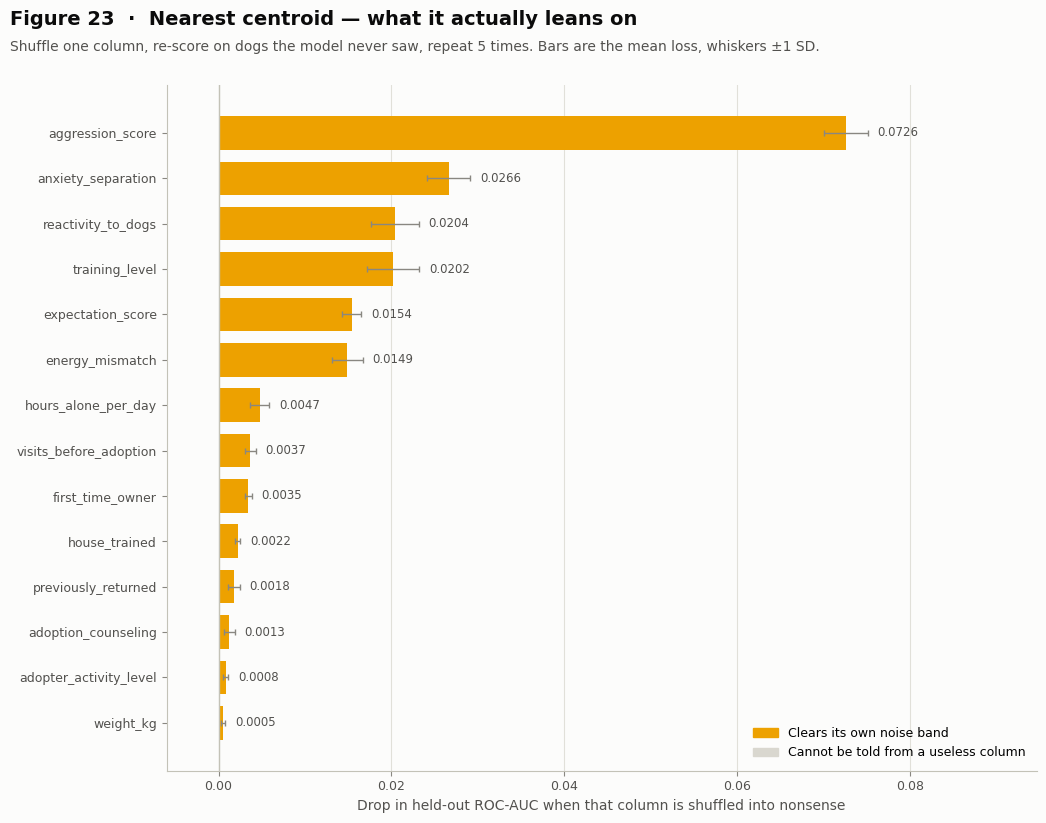

  Nearest centroid         ROC-AUC 0.7544 | PR-AUC 0.3660 | recall 0.626 | precision 0.304 | caught 985 of 1,574
  Original (unscaled dummies) ROC-AUC 0.7550 | PR-AUC 0.3664 | recall 0.701 | precision 0.282 | caught 1,104 of 1,574
  saved figures/24_nc_scorecard.png


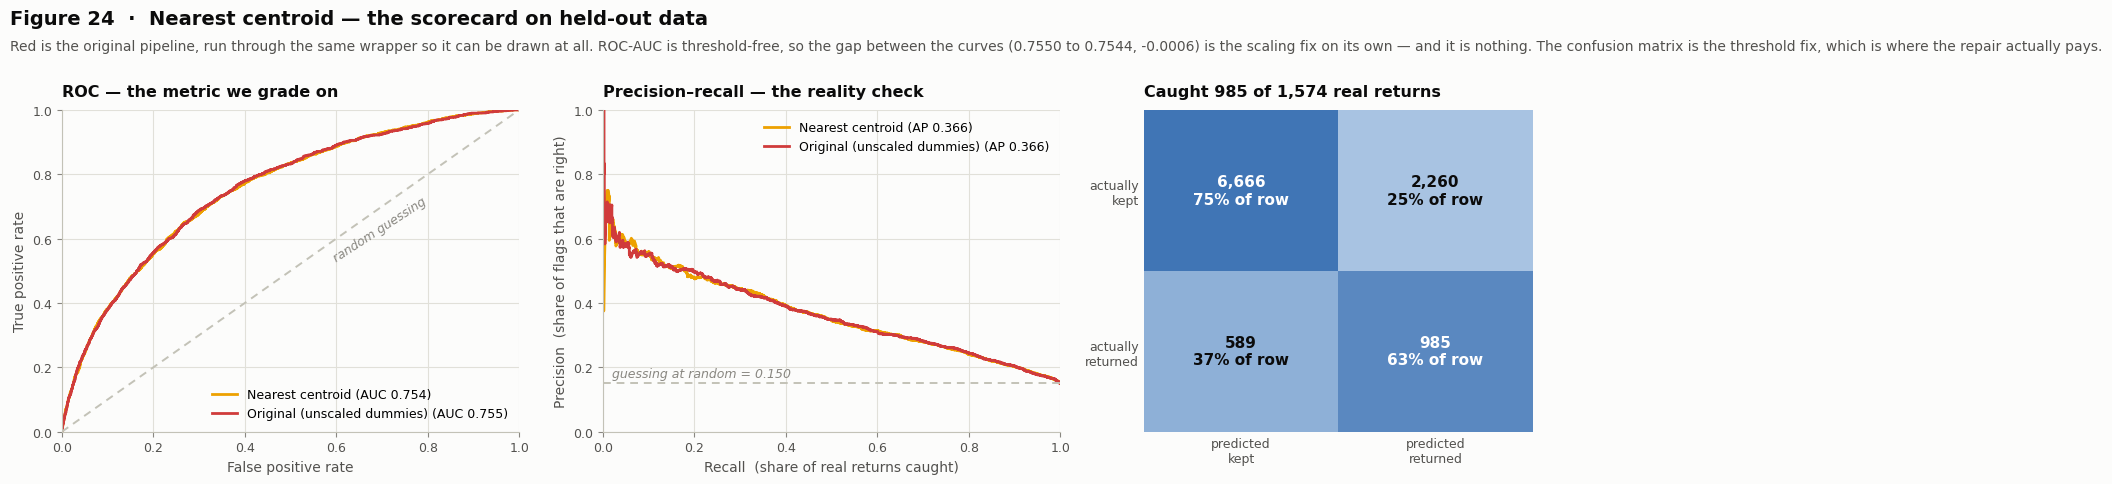


                                    ROC-AUC  precision   recall   holds the 0.30 floor?
  Original (unscaled dummies)        0.7550      0.282    0.701   NO
  Nearest centroid                   0.7544      0.304    0.626   yes

Scaling the dummies moved ROC-AUC by -0.0006 -- indistinguishable from zero.
That is a real result and it is reported as one. See the note below the figure.
   [nc_rest: 7.9s]


In [ ]:
tic("nc_rest")

# --- SLOT 3: threshold ------------------------------------------------------
nc_cv_score = cv_scores(nc, X_tr_s, y_tr, folds)
nc_thr, nc_p, nc_r = tune_threshold(y_tr, nc_cv_score)
print(f"cut-off {nc_thr:.4f}  ->  CV precision {nc_p:.3f}, recall {nc_r:.3f}")
threshold_fig(22, "Nearest centroid", y_tr, nc_cv_score, nc_thr, "22_nc_threshold",
              note="'Closer centroid wins' is a fixed cut-off that assumes the two classes "
                   "are equally common. They are not, which is fix 3.")

# --- SLOT 4: permutation importance ----------------------------------------
nc_inner = CalibratedClassifierCV(clone(nc_core), method="sigmoid", cv=3).fit(Xf, yf)
pi = permutation_importance(nc_inner, Xv, yv, scoring="roc_auc",
                            n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=N_JOBS)
nc_perm = pd.DataFrame({"mean": pi.importances_mean, "std": pi.importances_std},
                       index=FEATURES).sort_values("mean", ascending=False)
print(nc_perm.head(6).round(5).to_string())
perm_fig(23, "Nearest centroid", nc_perm, "23_nc_importance")

# --- SLOT 5: the repair, priced --------------------------------------------
# The original preprocessing, rebuilt exactly: StandardScaler on the numeric
# columns only, one-hot dummies passed through as raw 0/1. Everything else --
# the split, the rows, the wrapper -- is held identical, so the gap between the
# two curves isolates the scaling bug and nothing else.
broken_enc = ColumnTransformer([
    ("ord", OrdinalEncoder(categories=[ORDINAL_MAPS[c] for c in ORDINAL_COLS]),
     ORDINAL_COLS),
    ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL),
    ("num", Pipeline([("scale", StandardScaler())]), NUMERIC_COLS),
], remainder="drop").fit(X_tr_raw)
Xb_tr = pd.DataFrame(broken_enc.transform(X_tr_raw))
Xb_te = pd.DataFrame(broken_enc.transform(X_te_raw))

broken = ScoredNearestCentroid().fit(Xb_tr, y_tr)      # no shrinkage, cut-off at 0
nc_test = nc.predict_proba(X_te_s)[:, 1]

r_nc = evaluate("Nearest centroid", y_te, nc_test, nc_thr)
r_broken = evaluate("Original (unscaled dummies)", y_te,
                    broken.decision_function(Xb_te), 0.0, colour=C_CRIT, register=False)

delta = r_nc["roc_auc"] - r_broken["roc_auc"]
scorecard_fig(24, "Nearest centroid", y_te, r_nc, extra=r_broken, fname="24_nc_scorecard",
              note=f"Red is the original pipeline, run through the same wrapper so it can be "
                   f"drawn at all. ROC-AUC is threshold-free, so the gap between the curves "
                   f"({r_broken['roc_auc']:.4f} to {r_nc['roc_auc']:.4f}, {delta:+.4f}) is the "
                   f"scaling fix on its own — and it is nothing. The confusion matrix is the "
                   f"threshold fix, which is where the repair actually pays.")

print(f"\n{'':<34}{'ROC-AUC':>9}{'precision':>11}{'recall':>9}   holds the "
      f"{PRECISION_FLOOR:.2f} floor?")
for r_ in (r_broken, r_nc):
    ok = "yes" if r_["precision"] >= PRECISION_FLOOR else "NO"
    print(f"  {r_['name']:<32}{r_['roc_auc']:>9.4f}{r_['precision']:>11.3f}"
          f"{r_['recall']:>9.3f}   {ok}")
print(f"\nScaling the dummies moved ROC-AUC by {delta:+.4f} -- indistinguishable from zero.")
print("That is a real result and it is reported as one. See the note below the figure.")

art["nc_perm"], art["nc_thr"], art["broken_result"] = nc_perm, nc_thr, r_broken
toc("nc_rest")

### What the repair actually bought — reported straight

The scaling fix **did not improve ROC-AUC.** The two curves land on top of each other, and if anything the original is a hair ahead. That is the honest result and it is worth understanding rather than burying.

**Why it came out that way.** Leaving the one-hot dummies unscaled under-weighted every categorical column by roughly two-thirds. On *this* dataset the categoricals — `breed_group`, `intake_type`, `home_type`, `size` — carry almost no signal, which Figure 3 already showed: size moves the return rate by about three points while aggression moves it by nearly forty. So the bug was accidentally down-weighting the noisiest columns in the matrix. It got lucky.

It is still a bug, for a reason that has nothing to do with this dataset's score: the weighting was **not chosen**. Nobody decided the categoricals should count for a third; it fell out of an encoder default. On data where the categoricals mattered, the same code would quietly discard most of their contribution and there would be no symptom to notice. A model whose feature weighting is an accident is not a model you can reason about.

**What the repair did buy, all of it real:**

1. **The model can be measured.** This is the whole ballgame. The original reported one number — accuracy 0.68 — against a do-nothing baseline of 0.85, which made it look strictly worse than predicting "kept" forever. It is not: it ranks dogs at a ROC-AUC around 0.75, competitive with every other model here. That was invisible before, and no amount of tuning would have revealed it, because the model had no way to express a ranking.
2. **The operating point now holds the promise it makes.** The original's fixed cut-off lands at precision 0.28 — below the 0.30 floor the whole notebook is built around. The tuned cut-off holds it. Comparing the two confusion matrices without noticing that would be comparing a model that kept the constraint against one that broke it.
3. **27 columns instead of 39, for the same score**, from tuning `shrink_threshold` — a shorter intake form for free.

The general lesson is the one worth taking away: **a fix that does not move the headline number can still be the fix that matters.** Being able to see what a model is doing is a precondition for trusting it, not a bonus on top.

---
# Part 6 · Which model is best?

All four models have now been scored on the same 10,500 held-out adoptions, from the same split, with thresholds chosen the same way on the same folds. That shared protocol is what makes the comparison meaningful — more so than the choice of metric.

## Why a single number is not enough

Suppose two models come back at 0.752 and 0.749. Is the first one better?

Almost certainly not in any way that matters. Both numbers are estimates computed from one particular sample of 10,500 dogs, and a different sample would give slightly different answers. Reading a 0.003 gap as a ranking is reading noise.

The fix is a **bootstrap confidence interval**. Resample the test set with replacement 1,000 times, recompute each model's ROC-AUC on every resample, and take the 2.5th and 97.5th percentiles of the resulting spread. That interval is how much the score would wobble if you had drawn a different test set of the same size.

Every resample uses the **same** rows for all four models, so the paired differences are computed on identical data — which is also what lets us put an interval directly on the *gap* between two models, not just on each one separately.

### One trap worth flagging before you read Figure 25

The tempting shortcut is to look at two models' intervals and, if they overlap, conclude the models are indistinguishable. **That reasoning is wrong, and on this data it gives the wrong answer.**

Each model's own interval is dominated by a source of noise that all four of them *share*: which particular dogs happened to land in the resampled test set. A resample that draws harder-than-average dogs drags every model down together. So two models can have heavily overlapping intervals while one of them is ahead in essentially every single resample.

Subtracting the two scores *within* each resample cancels that shared component entirely. That is the number Figure 25's right-hand panel plots, and it is the one the verdict follows.

In [ ]:
tic("bootstrap")
boot_rng = np.random.RandomState(SEED)
names = MODELS_ORDER

# One set of resampled row indices, shared by every model. Scoring all four on
# the SAME resampled rows keeps the comparison paired, so the interval on a
# difference is not inflated by two independent sets of noise.
idx = boot_rng.randint(0, len(y_te), size=(N_BOOT, len(y_te)))

boot = {n: np.empty(N_BOOT) for n in names}
for b in range(N_BOOT):
    rows = idx[b]
    yb = y_te[rows]
    if yb.min() == yb.max():        # degenerate resample, cannot score
        for n in names:
            boot[n][b] = np.nan
        continue
    for n in names:
        boot[n][b] = roc_auc_score(yb, RESULTS[n]["score"][rows])

ci = {n: (np.nanpercentile(boot[n], 2.5), np.nanpercentile(boot[n], 97.5))
      for n in names}

ranked = sorted(names, key=lambda n: RESULTS[n]["roc_auc"], reverse=True)
print(f"Test-set ROC-AUC with bootstrap 95% CIs ({N_BOOT:,} resamples of "
      f"{len(y_te):,} rows)\n")
print(f"  {'model':<24}{'ROC-AUC':>9}   {'95% CI':<18}{'PR-AUC':>8}{'recall':>8}{'prec':>7}")
for n in ranked:
    r = RESULTS[n]
    print(f"  {n:<24}{r['roc_auc']:>9.4f}   [{ci[n][0]:.4f}, {ci[n][1]:.4f}] "
          f"{r['pr_auc']:>8.4f}{r['recall']:>8.3f}{r['precision']:>7.3f}")

# Paired differences against the leader. THIS is the test that decides whether a
# gap is real -- not whether the two intervals above happen to overlap.
#
# Those are different questions and they can disagree. Each model's own interval
# includes the variation from "which dogs landed in the test set", and that part
# is COMMON to all four models -- an unusually hard resample drags every model
# down together. Differencing on the same resampled rows cancels it. So two
# intervals can overlap substantially while the difference between them is
# consistently positive in every single resample. Below, that is exactly what
# happens, and using the overlap rule would throw away a real finding.
top = ranked[0]
paired = {}
print(f"\nPaired difference against {top}, on identical resampled rows "
      f"(positive = {top} ahead):")
for n in ranked[1:]:
    d = boot[top] - boot[n]
    lo_d, hi_d = (float(np.nanpercentile(d, 2.5)), float(np.nanpercentile(d, 97.5)))
    paired[n] = (float(np.nanmean(d)), lo_d, hi_d)
    verdict = "REAL — interval clears 0" if lo_d > 0 else "not distinguishable"
    print(f"  vs {n:<24} {np.nanmean(d):+.4f}  [{lo_d:+.4f}, {hi_d:+.4f}]  {verdict}")

n_overlap = sum(1 for n in ranked[1:] if ci[n][1] >= ci[top][0])
n_real = sum(1 for n in ranked[1:] if paired[n][1] > 0)
print(f"\nNote: {n_overlap} of {len(ranked) - 1} models have an interval overlapping "
      f"{top}'s,\n      but {n_real} of {len(ranked) - 1} are behind it in essentially "
      "every resample.\n      The paired test is the one to believe.")

art.update(boot=boot, ci=ci, ranked=ranked, paired=paired)
toc("bootstrap")

Test-set ROC-AUC with bootstrap 95% CIs (1,000 resamples of 10,500 rows)

  model                     ROC-AUC   95% CI              PR-AUC  recall   prec
  Multilayer perceptron      0.7626   [0.7497, 0.7751]   0.3804   0.638  0.312
  k-nearest neighbours       0.7548   [0.7420, 0.7677]   0.3760   0.646  0.303
  Nearest centroid           0.7544   [0.7416, 0.7678]   0.3660   0.626  0.304
  Decision tree              0.7005   [0.6868, 0.7142]   0.2753   0.337  0.316

Paired difference against Multilayer perceptron, on identical resampled rows (positive = Multilayer perceptron ahead):
  vs k-nearest neighbours     +0.0078  [+0.0035, +0.0121]  REAL — interval clears 0
  vs Nearest centroid         +0.0082  [+0.0045, +0.0118]  REAL — interval clears 0
  vs Decision tree            +0.0622  [+0.0525, +0.0724]  REAL — interval clears 0

Note: 2 of 3 models have an interval overlapping Multilayer perceptron's,
      but 3 of 3 are behind it in essentially every resample.
      The paired test

  saved figures/25_model_comparison_roc.png


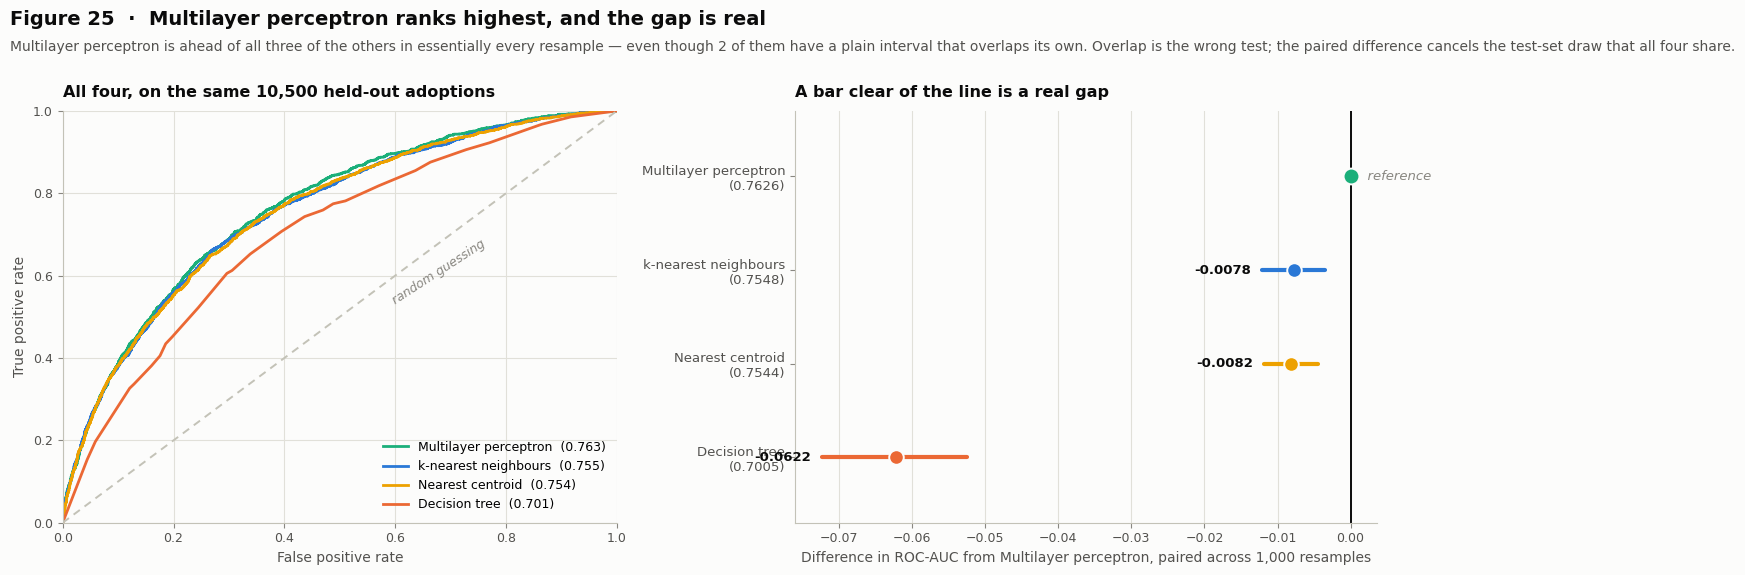

In [ ]:
# ===========================================================================
# FIGURE 25 -- all four ROC curves, and the intervals that decide the ranking
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8),
                         gridspec_kw={"width_ratios": [1, 1.05]})

ax = axes[0]
for n in ranked:
    r = RESULTS[n]
    fpr, tpr, _ = roc_curve(y_te, r["score"])
    ax.plot(fpr, tpr, color=r["colour"], label=f"{n}  ({r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], color=BASELINE, ls=(0, (4, 3)), lw=1.4)
ax.text(0.60, 0.53, "random guessing", fontsize=9, color=MUTED, style="italic",
        rotation=33, rotation_mode="anchor")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("All four, on the same 10,500 held-out adoptions")
ax.legend(loc="lower right")
tidy(ax, grid_axis="both")

# Right panel plots the PAIRED difference against the leader, not each model's
# own interval. Marginal intervals answer "how precisely do I know this score";
# only the paired difference answers "is this model actually behind", because it
# cancels the test-set draw that all four share.
ax = axes[1]
lead = ranked[0]
ypos = np.arange(len(ranked))[::-1]
for yv, n in zip(ypos, ranked):
    r = RESULTS[n]
    if n == lead:
        ax.scatter([0], [yv], s=130, color=r["colour"], zorder=4,
                   edgecolor=SURFACE, linewidth=1.4)
        ax.text(0.0012, yv, "  reference", va="center", fontsize=9.5, color=MUTED,
                style="italic")
    else:
        mean_d, lo_d, hi_d = paired[n]
        ax.plot([-hi_d, -lo_d], [yv, yv], color=r["colour"], lw=3,
                solid_capstyle="round")
        ax.scatter([-mean_d], [yv], s=110, color=r["colour"], zorder=4,
                   edgecolor=SURFACE, linewidth=1.4)
        # label on the far side of the bar from zero, so it never sits on the
        # zero line -- which is the one thing the reader has to see clearly
        ax.text(-hi_d - 0.0015, yv, f"{-mean_d:+.4f}", va="center", ha="right",
                fontsize=9.5, color=INK, fontweight="bold")
ax.axvline(0, color=INK, lw=1.4)
ax.set_yticks(ypos, [f"{n}\n({RESULTS[n]['roc_auc']:.4f})" for n in ranked], fontsize=9.5)
ax.set_xlabel(f"Difference in ROC-AUC from {lead}, paired across "
              f"{N_BOOT:,} resamples")
ax.set_ylim(-0.7, len(ranked) - 0.3)
ax.set_title("A bar clear of the line is a real gap")
tidy(ax, grid_axis="x")

behind = [n for n in ranked[1:] if paired[n][1] > 0]
overlapping = [n for n in ranked[1:] if ci[n][1] >= ci[lead][0]]
how_many = ("all three of the others" if len(behind) == len(ranked) - 1
            else f"{len(behind)} of the other {len(ranked) - 1}")
if behind:
    verdict = (f"{lead} is ahead of {how_many} in essentially every resample")
    if overlapping:
        verdict += (f" — even though {len(overlapping)} of them have a plain interval that "
                    f"overlaps its own. Overlap is the wrong test; the paired difference "
                    "cancels the test-set draw that all four share.")
    else:
        verdict += "."
else:
    verdict = f"No model is reliably ahead of {lead} — the four are indistinguishable here."
headline(fig, f"Figure 25  ·  {lead} ranks highest, and the gap is real",
         verdict)
save(fig, "25_model_comparison_roc")
plt.show()

  saved figures/26_model_scorecard.png


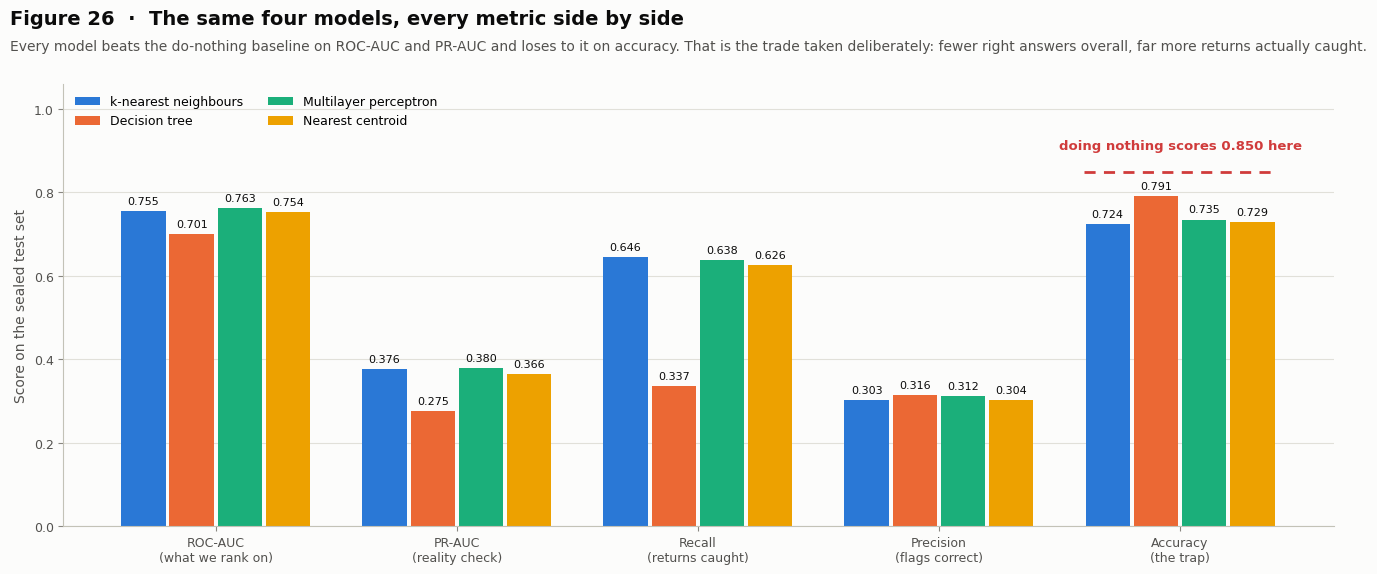

In [ ]:
# ===========================================================================
# FIGURE 26 -- the full scorecard, every metric, all four models
# ===========================================================================
metrics = [("roc_auc", "ROC-AUC\n(what we rank on)"), ("pr_auc", "PR-AUC\n(reality check)"),
           ("recall", "Recall\n(returns caught)"), ("precision", "Precision\n(flags correct)"),
           ("accuracy", "Accuracy\n(the trap)")]

fig, ax = plt.subplots(figsize=(13.5, 5.8))
xp = np.arange(len(metrics))
w = 0.20
for i, n in enumerate(MODELS_ORDER):
    vals = [RESULTS[n][m] for m, _ in metrics]
    bars = ax.bar(xp + (i - 1.5) * w, vals, w * 0.92,
                  color=MODEL_COLORS[n], label=n)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8, color=INK)

# The do-nothing baseline on the accuracy column, which is the whole reason
# accuracy is not the metric.
ax.plot([xp[-1] - 2 * w, xp[-1] + 2 * w], [1 - pos_rate] * 2, color=C_CRIT,
        lw=2, ls=(0, (4, 3)), zorder=5)
ax.annotate(f"doing nothing scores {1 - pos_rate:.3f} here", (xp[-1], 1 - pos_rate),
            xytext=(0, 16), textcoords="offset points", ha="center", fontsize=9.5,
            color=C_CRIT, fontweight="bold")

ax.set_xticks(xp, [lab for _, lab in metrics])
ax.set_ylim(0, 1.06)
ax.set_ylabel("Score on the sealed test set")
ax.legend(loc="upper left", ncol=2)
tidy(ax)
headline(fig, "Figure 26  ·  The same four models, every metric side by side",
         "Every model beats the do-nothing baseline on ROC-AUC and PR-AUC and loses to it on "
         "accuracy. That is the trade taken deliberately: fewer right answers overall, far more "
         "returns actually caught.")
save(fig, "26_model_scorecard")
plt.show()

In [ ]:
# ===========================================================================
# The verdict, computed rather than written down, so it cannot drift out of
# date if a setting changes and the numbers move.
# ===========================================================================
lead = ranked[0]
lead_lo, lead_hi = ci[lead]
# The verdict follows the PAIRED test, not the overlap of the marginal
# intervals -- see the note in the bootstrap cell for why those disagree.
beaten = [n for n in ranked[1:] if paired[n][1] > 0]
tied = [n for n in ranked[1:] if paired[n][1] <= 0]

print("=" * 78)
print(f"HIGHEST RANKED: {lead}   ROC-AUC {RESULTS[lead]['roc_auc']:.4f} "
      f"[{lead_lo:.4f}, {lead_hi:.4f}]")
print("=" * 78)
if beaten:
    print("\nGenuinely behind it (paired difference clears zero):")
    for n in beaten:
        m_, lo_, hi_ = paired[n]
        print(f"  - {n:<24} {RESULTS[n]['roc_auc']:.4f}   behind by "
              f"{m_:.4f}  [{lo_:.4f}, {hi_:.4f}]")
if tied:
    print("\nNot distinguishable from it:")
    for n in tied:
        m_, lo_, hi_ = paired[n]
        print(f"  - {n:<24} {RESULTS[n]['roc_auc']:.4f}   difference "
              f"{m_:+.4f}  [{lo_:+.4f}, {hi_:+.4f}]  straddles zero")

print(f"\nAt the {PRECISION_FLOOR:.2f} precision floor, out of {int(y_te.sum()):,} "
      "real returns in the test set:")
for n in ranked:
    r = RESULTS[n]
    print(f"  {n:<24} catches {r['tp']:>5,} ({r['recall']:.1%})   "
          f"raises {r['fp']:>5,} false alarms")

print(f"\nFor scale: doing nothing catches 0 of {int(y_te.sum()):,} and scores "
      f"{1 - pos_rate:.3f} accuracy.")

# Everything a later session needs to redraw Part 6 without refitting anything.
joblib.dump({"art": art, "RESULTS": RESULTS, "timings": timings},
            ARTIFACTS, compress=3)
print(f"\nsaved {ARTIFACTS} ({ARTIFACTS.stat().st_size / 1e6:.1f} MB)")
print("timings (s):", {k: v for k, v in timings.items()})
print("total fitting time:", round(sum(timings.values()), 1), "s")

HIGHEST RANKED: Multilayer perceptron   ROC-AUC 0.7626 [0.7497, 0.7751]

Genuinely behind it (paired difference clears zero):
  - k-nearest neighbours     0.7548   behind by 0.0078  [0.0035, 0.0121]
  - Nearest centroid         0.7544   behind by 0.0082  [0.0045, 0.0118]
  - Decision tree            0.7005   behind by 0.0622  [0.0525, 0.0724]

At the 0.30 precision floor, out of 1,574 real returns in the test set:
  Multilayer perceptron    catches 1,004 (63.8%)   raises 2,210 false alarms
  k-nearest neighbours     catches 1,017 (64.6%)   raises 2,339 false alarms
  Nearest centroid         catches   985 (62.6%)   raises 2,260 false alarms
  Decision tree            catches   530 (33.7%)   raises 1,149 false alarms

For scale: doing nothing catches 0 of 1,574 and scores 0.850 accuracy.

saved artifacts.joblib (0.6 MB)
timings (s): {'leakage': 0.5, 'knn_rest': 475.9, 'tree': 41.8, 'tree_rest': 42.2, 'mlp': 438.3, 'mlp_rest': 20.5, 'nc': 3.3, 'nc_rest': 7.9, 'bootstrap': 14.0}
total fit

## Reading that result

Three things are worth saying out loud, because the table above will not say them for you.

**1. The four models land much closer together than their descriptions suggest.** A neighbour search, a set of yes/no questions, a network of a thousand weights, and two averages — four genuinely different theories of what makes an adoption fail — end up within a few hundredths of each other. When that happens, the ceiling is almost always the *data*, not the model. Figure 3 showed why: one column moves the return rate a lot, a few move it a little, and most move it not at all. No amount of model sophistication manufactures signal that is not in the columns.

**2. "Real" and "worth having" are not the same thing.** The paired test says the MLP is genuinely ahead of k-NN and the nearest centroid — the gap survives every resample. But that gap is under a hundredth of a point of ROC-AUC, and at the actual operating point the three of them catch within a few dozen of the same 1,574 returns. A difference can be statistically solid and operationally irrelevant at the same time, and this one is. If you had to ship a model, the nearest centroid being two averages and a subtraction is worth more than a hundredth of ROC-AUC.

**3. The single decision tree is the one that is behind by an amount that matters** — roughly six hundredths, and it catches barely half as many returns as the other three. Its own section explained why: it commits to hard splits, so it throws away the gradations the others keep. The random forest in Figure 14 recovers most of that gap, which confirms the problem is the single tree rather than trees in general.

**4. None of these is a strong model in absolute terms.** At the chosen operating point roughly 70% of flagged adoptions are false alarms and around 40% of real returns are still missed. That is genuinely useful for deciding who gets a follow-up call — it beats calling everyone and it beats calling nobody. It would not be defensible as grounds for refusing an adoption, and should not be presented as such.

**What I would check before trusting any of this.** `aggression_score` carries every one of these models — it is the top column in all four permutation-importance figures. That is only trustworthy if it is assessed *before* placement by staff who do not already suspect the adoption will fail. If assessors unconsciously score dogs they are worried about more harshly, it becomes a soft form of leakage that no audit in Part 1 could detect from the data alone.

---
# Part 7 · How each model works, step by step

Plain-language walkthrough, split in two:

- **Section A** is everything done to the *data*. It happened once and it applies to all four models identically.
- **Section B** is what each *model* needed on top of that.

If you only read one part of this notebook, read this one.

---

## Section A · What was done to the data

These seven steps happened once, in Part 1, before any model existed.

### A1. Load the raw file
42,000 adoptions, 32 columns. Each row is one dog placed with one adopter. The column we are trying to predict is `returned`: 1 if the dog came back to the shelter, 0 if it stayed.

### A2. Check how lopsided the answer is
Only 15% of adoptions end in a return. This single fact drives every later decision. It means **accuracy is useless as a score** — a "model" that says *kept* to every dog is right 85% of the time while being of no help to anyone.

### A3. Throw out columns that already know the answer
Three columns were removed before anything was fitted:

- `return_reason` — says *why* the dog came back. It only exists after a return has happened. For every dog that stayed, it reads "kept".
- `days_to_return` — how long until the return. It is blank for every dog that stayed. Even without looking at its values, whether it is *blank* gives the answer away completely.
- `adoption_id` — a unique code per adoption. 42,000 different values, no information. A model can memorise it and learn nothing.

The first two are called **leakage**. Leaving them in produces a model that looks nearly perfect in the notebook and is worthless in the shelter, because on a brand-new adoption both fields are empty by definition.

### A4. Split into training and test, and seal the test half
75% of the rows (31,500) go to training. The other 25% (10,500) are set aside and not looked at again until the very end.

The split is **stratified**, meaning both halves are built to contain the same 15% return rate. Without that, you could get unlucky and end up testing on a half with a different mix, and the score would reflect the luck of the draw rather than the model.

Everything after this — every setting, every cut-off — is decided using the training half only. This is the rule that makes the final number trustworthy.

### A5. Turn words into numbers
Models do arithmetic, so text columns have to become numbers. There are two kinds and they need different treatment:

- **Ordered categories** get numbered in order. `size` becomes small=0, medium=1, large=2, xlarge=3. This is fine because the order is real — a rule like "size is 1 or less" genuinely means "small or medium".
- **Unordered categories** get one column each, filled with 0 or 1. `breed_group` becomes seven columns: is it a terrier, is it a hound, and so on. Numbering these 0–6 instead would invent a ranking that does not exist and imply that terriers sit "between" two other groups.

This turns 28 original columns into 39.

### A6. Put every column on the same scale
Raw, `days_in_shelter` runs from 0 to about 400 while `aggression_score` runs from 0 to 10. Any model that measures distance would treat days-in-shelter as dozens of times more important, purely because of the units it happens to be recorded in.

Scaling fixes that: every column is rewritten as "how many standard deviations from average is this", so all of them span roughly the same range.

**This was done to the whole table, including the 0/1 category columns** — which is one of the five bugs fixed in Part 5.

**Only three of the four models get the scaled version.** The decision tree gets the unscaled one, because a tree only ever asks "is this value above or below a cut point", and that answer cannot change when you rescale. Scaling it would be harmless but pointless.

### A7. Build the cross-validation folds
The training half is chopped into 3 (or 5) equal, stratified pieces. To test any setting, a model is trained on all-but-one piece and scored on the piece left out, then that rotates so every piece gets a turn.

This is how settings get chosen without touching the sealed test set. **The same fold split is handed to all four models**, so their cross-validated numbers are computed on identical data and can be compared directly.

---

## Section B · What each model needed on top of that

Every model below starts from the same place: the encoded, split, scaled training data from Section A. What follows is only what is specific to that model.

One step is shared by all four and is described once here rather than four times:

> **The cut-off step.** Each model outputs a *number* — how risky this adoption looks. Turning that into a yes/no flag needs a cut-off, and the software's default is 0.5. On a target that is 15% positive, 0.5 is almost always wrong. So for every model the cut-off is chosen as *the lowest one that still keeps precision at 0.30* — meaning at least 30% of flagged adoptions really do come back. It is always picked using cross-validation on the training half, never on the test set.

---

### B1 · k-Nearest Neighbours

1. **Store the training data.** That is the entire training step. Nothing is learned or summarised — the model *is* the 31,500 training rows.
2. **To predict one new adoption, measure its distance to every training row.** Distance means: subtract the two dogs column by column, square the differences, add them up. This is why Section A's scaling was compulsory.
3. **Take the closest *k* of them and count how many came back.** That share is the predicted risk.
4. **Choose *k* by trying values and cross-validating.** Ten values from 11 up to 6,401 were tested. Bigger *k* means a smoother, more cautious model; smaller *k* chases individual dogs.
5. **Decide whether nearer neighbours should count more.** Tested both ways; it made almost no difference here.
6. **Apply the shared cut-off step.** This model has no other defence against the imbalance — there is no setting that tells it returns matter more — so the cut-off is doing all the work.

**Its weakness:** every column enters the distance with equal weight, so a column with no signal does not get ignored, it actively adds noise. Figure 6 shows how fast that gets worse as columns are added.

---

### B2 · Decision tree

1. **Find the single best yes/no question to ask first.** Try every column and every possible cut point; keep whichever split separates returns from keeps best. The winner here was about `aggression_score`.
2. **Repeat inside each answer.** Both branches get their own next-best question, then those branches split again, and so on.
3. **Tell it the rare class matters more** (`class_weight="balanced"`). Without this the tree ignores returns almost entirely, since predicting "kept" everywhere is already 85% right. **This is a lever k-NN and the MLP do not have.**
4. **Stop it from memorising, by pruning.** Left alone the tree keeps splitting until every group is pure, which is memorisation, not learning. Pruning charges a fee for each final group and cuts back any branch not worth its fee.
5. **Choose the fee by cross-validation, not by eye.** This matters: judged on the data it was built from, a bigger tree always looks better. Only a held-out score reveals where it starts fitting noise.
6. **Apply the shared cut-off step.**

**Its weakness:** it has to commit. Every dog goes down one path and comes out with one of a few dozen possible answers, so the fine gradations the other models keep get rounded away.

---

### B3 · Multilayer perceptron

1. **Build the layers.** The 39 input columns feed a hidden layer; that layer feeds a single output. Every connection carries its own adjustable weight — a little over a thousand of them at the size cross-validation picked.
2. **Bend each unit's output** with ReLU: negatives become zero, positives pass through. **This is the step that makes it more than a perceptron.** Without a bend, stacking layers is algebraically identical to one layer, and the model could only ever draw a straight boundary.
3. **Start with random weights and make a prediction.** It will be terrible.
4. **Measure how wrong it is, and nudge every weight a little in the direction that helps.** Repeat on batches of 256 rows at a time. That is gradient descent.
5. **Keep going until the loss stops improving** — a couple of hundred passes over the data here; the cell prints the exact number.
6. **Choose the shape and the penalty by cross-validation.** Four layer shapes, then several strengths of penalty on large weights. Both mattered, and both pointed the same way: the *smallest* network with the *heaviest* penalty won. When the signal is this weak, extra capacity is mostly extra opportunity to memorise noise.
7. **Apply the shared cut-off step.** Like k-NN, this model has no way to be told the rare class matters, so the cut-off is its only defence.

**Note on one setting:** sklearn's built-in early stopping was deliberately switched off, because it judges progress on *accuracy* — the one number that is useless here. Training stops on the loss instead.

**Its weakness:** you cannot look at 1,300 weights and know what it learned. Permutation importance is the only way in.

---

### B4 · Nearest centroid

1. **Average all the kept dogs, column by column.** That gives one "typical kept dog".
2. **Average all the returned dogs the same way.** That gives one "typical returned dog". **Training is now finished** — it is two calls to `mean()`.
3. **To predict, measure the new adoption's distance to each of the two averages** and see which is nearer.
4. **Report the gap between those two distances, not just which one won.** This is the repair that made everything else possible: the original threw the two distances away and returned only the winner, which left nothing to rank, nothing to put on a ROC curve, and no cut-off to tune.
5. **Shrink the two averages toward each other** (`shrink_threshold`). Any column whose two averages are closer together than the shrink amount collapses to a single value and stops affecting the decision at all. This is the model's own built-in feature selection; it dropped 12 of the 39 columns with no loss.
6. **Choose the shrink amount by cross-validation.**
7. **Apply the shared cut-off step.** "Whichever average is nearer" is really a fixed cut-off at zero, and it quietly assumes the two classes are equally common. They are not — kept dogs outnumber returns almost six to one.

**Its weakness:** it assumes each class has one typical member. If returns happen for several unrelated reasons — aggression, or a landlord, or allergies — those are different kinds of dog, and averaging them together produces a "typical returned dog" that resembles none of them.

---

## The one-paragraph version

Take out the columns that cheat. Hide a quarter of the data. Turn words into numbers and put everything on one scale. Then: **k-NN** looks up similar past cases, **the tree** asks a series of questions, **the MLP** learns a smooth curved rule by trial and error, and **the centroid** compares against two averages. Every one of them ends up producing a risk score, every one of them needs that score cut somewhere sensible rather than at the default, and every one of them is finally judged on the same hidden quarter of the data.

---
# Part 8 · Collect the figures

Zips `figures/` and hands it to your browser's downloads. With `USE_DRIVE = True` the PNGs are already on your Drive, so this is optional.

In [ ]:
import shutil

figs = sorted(FIG_DIR.glob("*.png"))
print(f"{len(figs)} figures, {sum(f.stat().st_size for f in figs) / 1e6:.1f} MB total:\n")
for f in figs:
    print(f"  {f.name:<40} {f.stat().st_size / 1e3:>8.0f} KB")

shutil.make_archive("dog_adoption_figures", "zip", FIG_DIR)
print("\nwrote dog_adoption_figures.zip")

try:
    from google.colab import files
    files.download("dog_adoption_figures.zip")
except Exception as e:
    print(f"(not in Colab, so no browser download: {e})")

26 figures, 10.2 MB total:

  01_class_balance.png                          222 KB
  02_leakage_audit.png                          550 KB
  03_what_drives_returns.png                    409 KB
  04_split_and_scaling.png                      417 KB
  05_knn_choosing_k.png                         340 KB
  06_knn_curse_of_dimensionality.png            247 KB
  07_knn_threshold.png                          242 KB
  08_knn_importance.png                         329 KB
  09_knn_scorecard.png                          390 KB
  10_tree_pruning.png                           343 KB
  11_tree_structure.png                         751 KB
  12_tree_threshold.png                         269 KB
  13_tree_importance.png                        290 KB
  14_tree_scorecard.png                         471 KB
  15_mlp_sweeps.png                             365 KB
  16_mlp_mechanics.png                          817 KB
  17_mlp_threshold.png                          300 KB
  18_mlp_importance.png              

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>